In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Scatterplots and Correlation

In [3]:
fuel_econ = pd.read_csv('../data/fuel_econ.csv')
fuel_econ.head(10)
#fuel_econ.size
#fuel_econ['drive'].unique()
#fuel_econ['VClass'].unique()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,79,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,94,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,0,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8
5,32209,Lexus,GS 350,2013,Midsize Cars,Rear-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.5,0,99,19.4325,24.1499,28.2234,38.5000,22.6002,393,6,6
6,32210,Lexus,GS 350 AWD,2013,Midsize Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.5,0,99,18.5752,23.5261,26.3573,36.2109,21.4213,412,5,5
7,32214,Hyundai,Genesis Coupe,2013,Subcompact Cars,Rear-Wheel Drive,Automatic 8-spd,Premium Gasoline,4,2.0,89,0,17.4460,21.7946,26.6295,37.6731,20.6507,432,5,5
8,32215,Hyundai,Genesis Coupe,2013,Subcompact Cars,Rear-Wheel Drive,Manual 6-spd,Premium Gasoline,4,2.0,89,0,20.6741,26.2000,29.2741,41.8000,23.8235,375,6,6
9,32216,Hyundai,Genesis Coupe,2013,Subcompact Cars,Rear-Wheel Drive,Automatic 8-spd,Premium Gasoline,6,3.8,89,0,16.4675,20.4839,24.5605,34.4972,19.3344,461,4,4


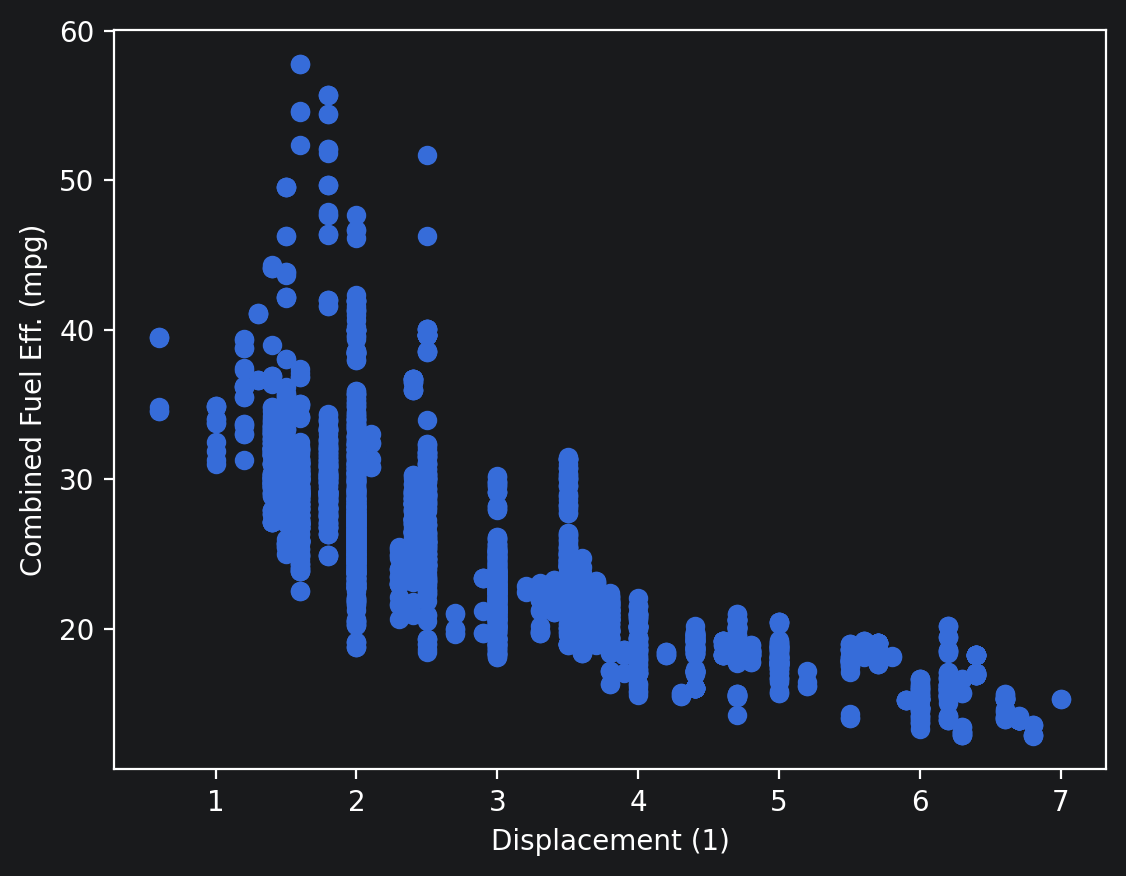

In [4]:
plt.scatter(data=fuel_econ, x='displ', y='comb')
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

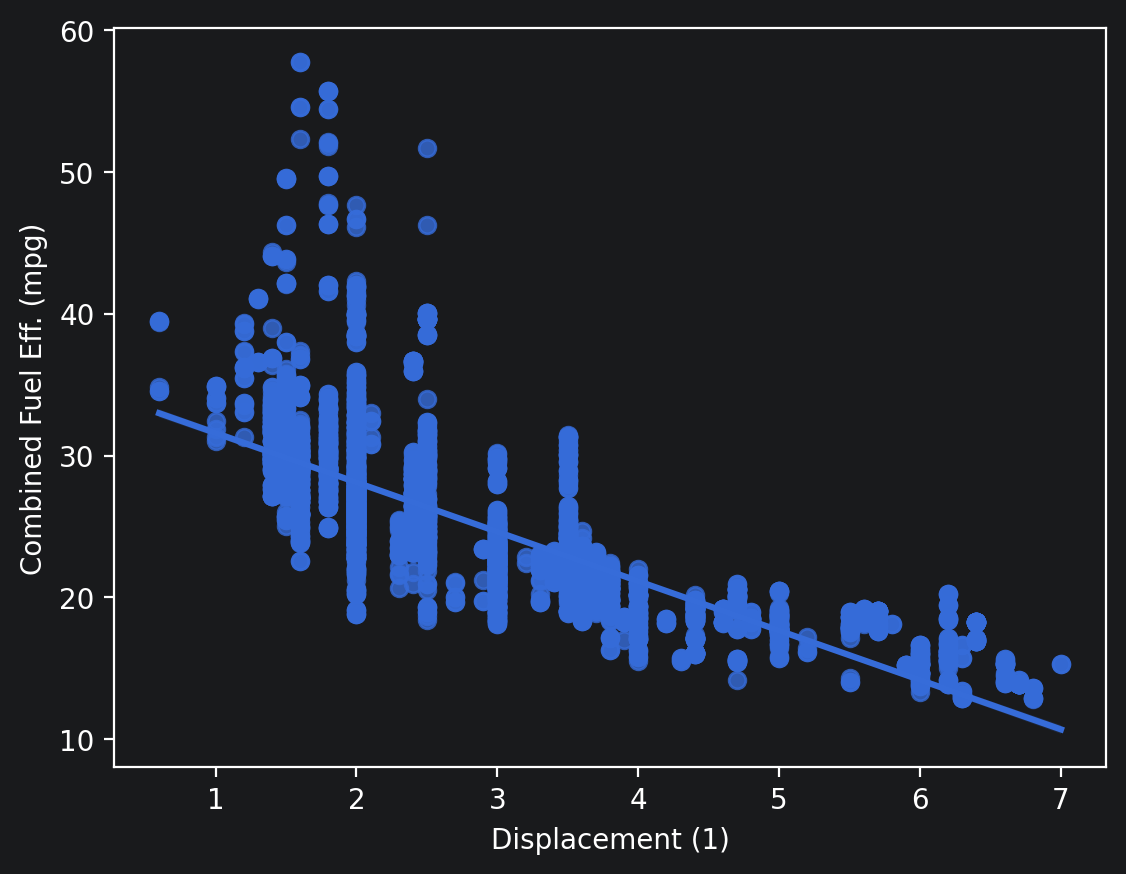

In [5]:
sns.regplot(data=fuel_econ, x='displ', y='comb', fit_reg=True)
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

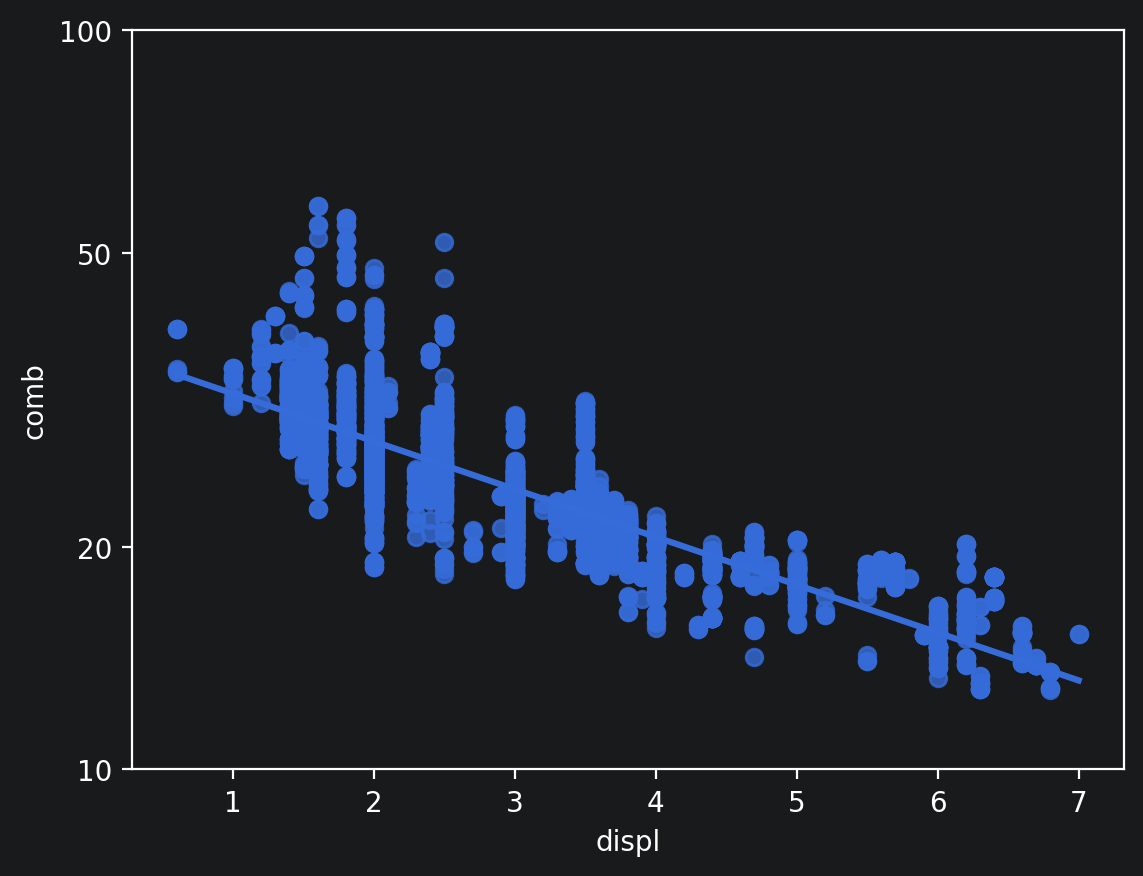

In [6]:
# Plot the regression line on the transformed data
def log_trans(x, inverse=False):
    if not inverse:
        return np.log10(x)
    else:
        return np.power(10, x)


sns.regplot(data=fuel_econ, x=fuel_econ['displ'], y=fuel_econ['comb'].apply(log_trans))
tick_locs = [10, 20, 50, 100]
plt.yticks(log_trans(tick_locs), tick_locs);

### Overplotting, Transparency, and Jitter

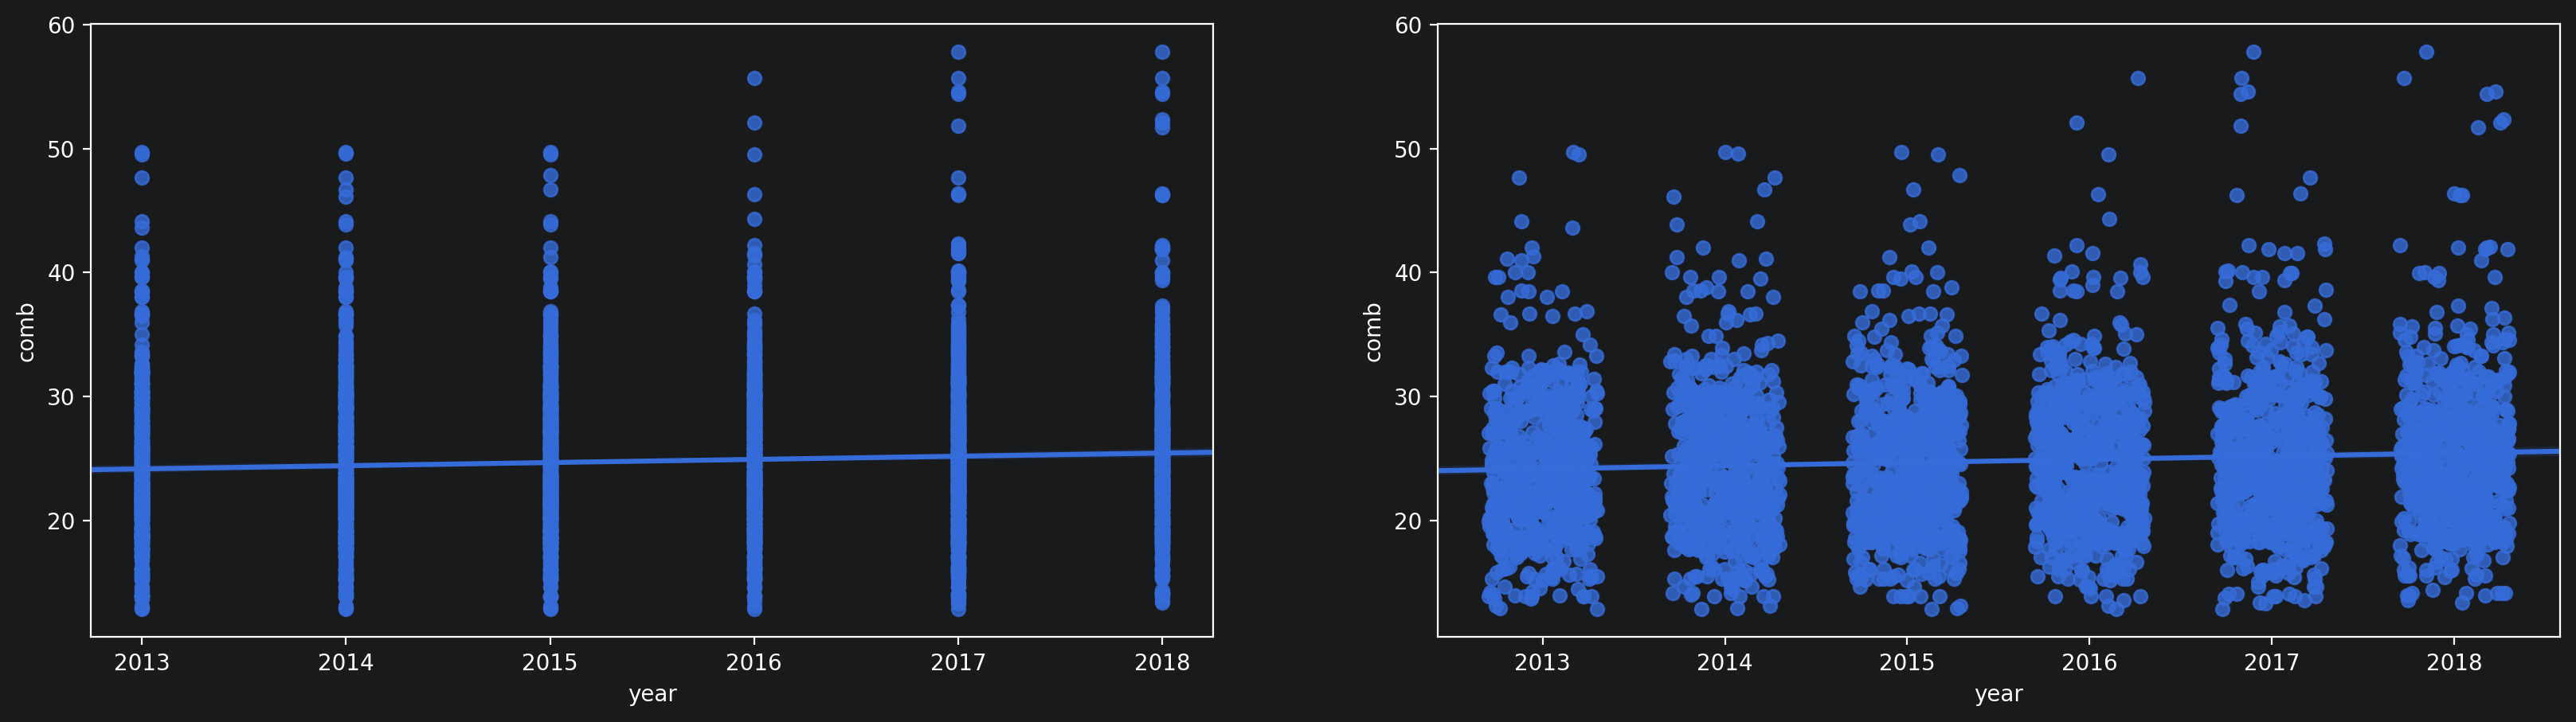

In [7]:
plt.figure(figsize=[20, 5])

plt.subplot(1, 2, 1)
sns.regplot(data=fuel_econ, x='year', y='comb', truncate=False)
plt.subplot(1, 2, 2)
sns.regplot(data=fuel_econ, x='year', y='comb', truncate=False, x_jitter=0.3);

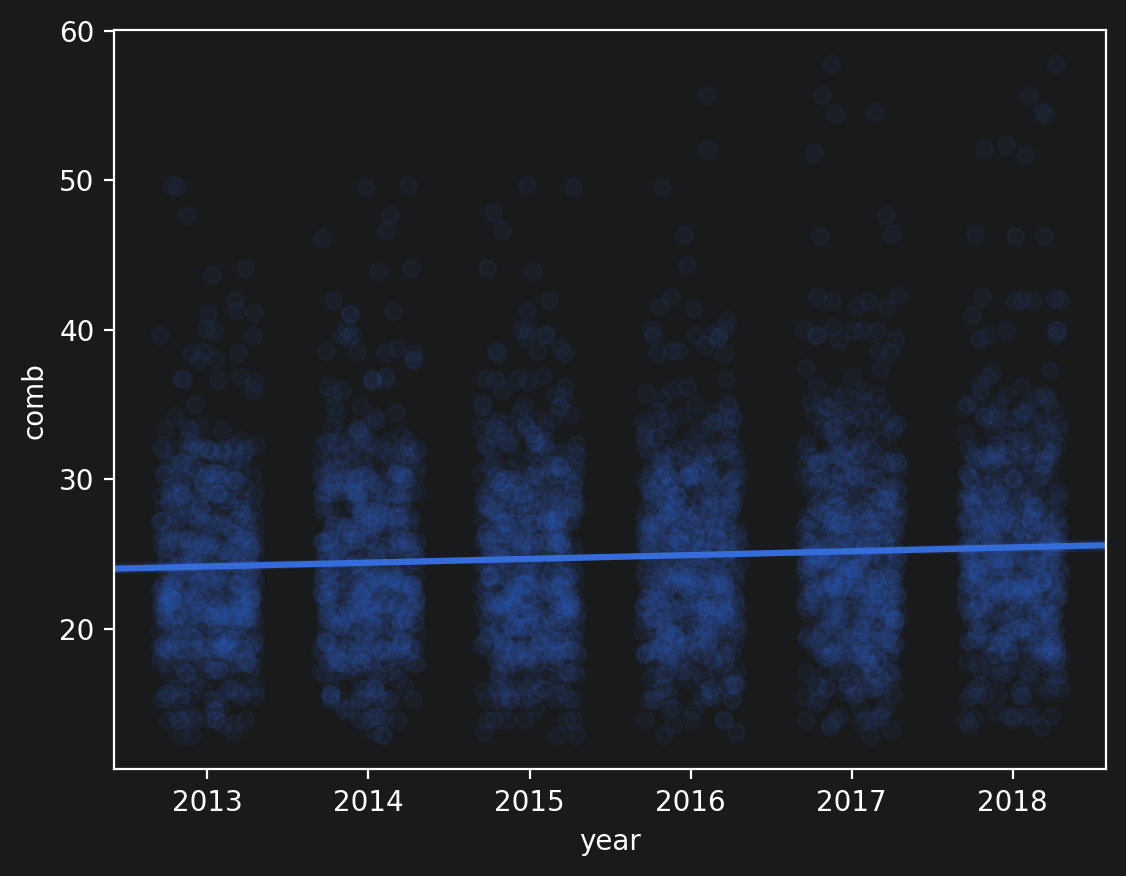

In [8]:
sns.regplot(data=fuel_econ, x='year', y='comb', truncate=False, x_jitter=0.3, scatter_kws={'alpha': 1 / 20});

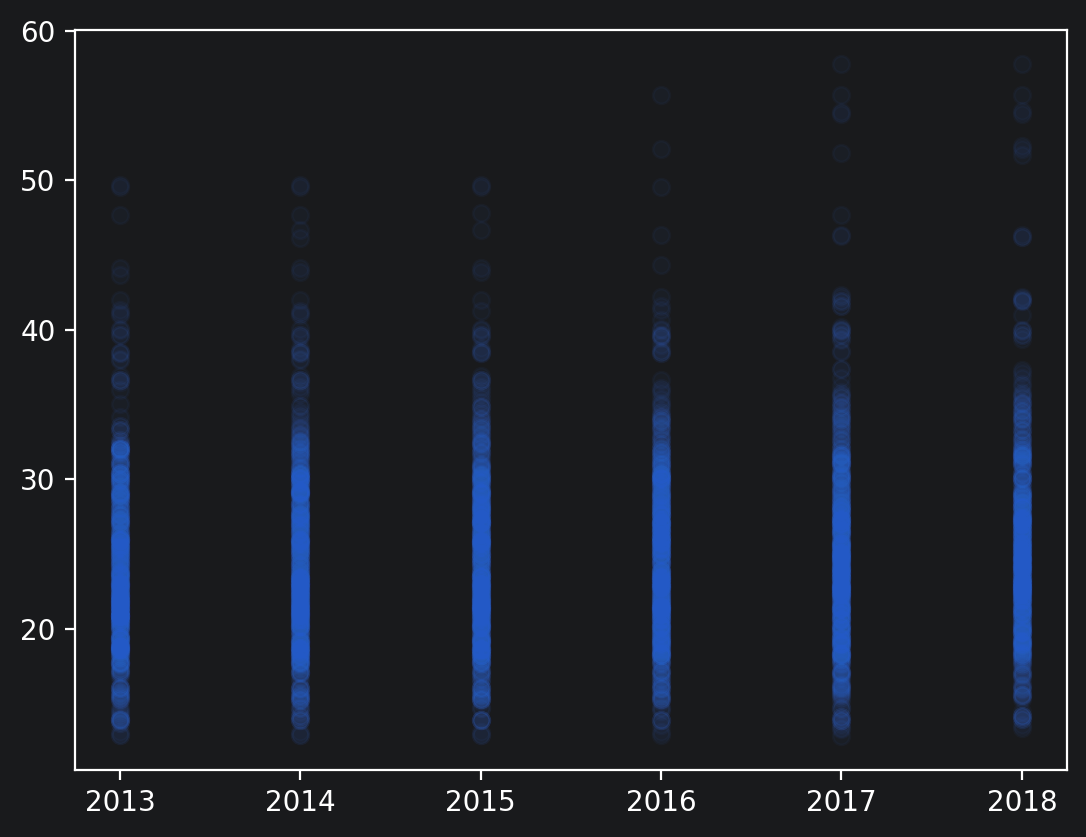

In [9]:
plt.scatter(data=fuel_econ, x='year', y='comb', alpha=1 / 20);

### Heat Maps

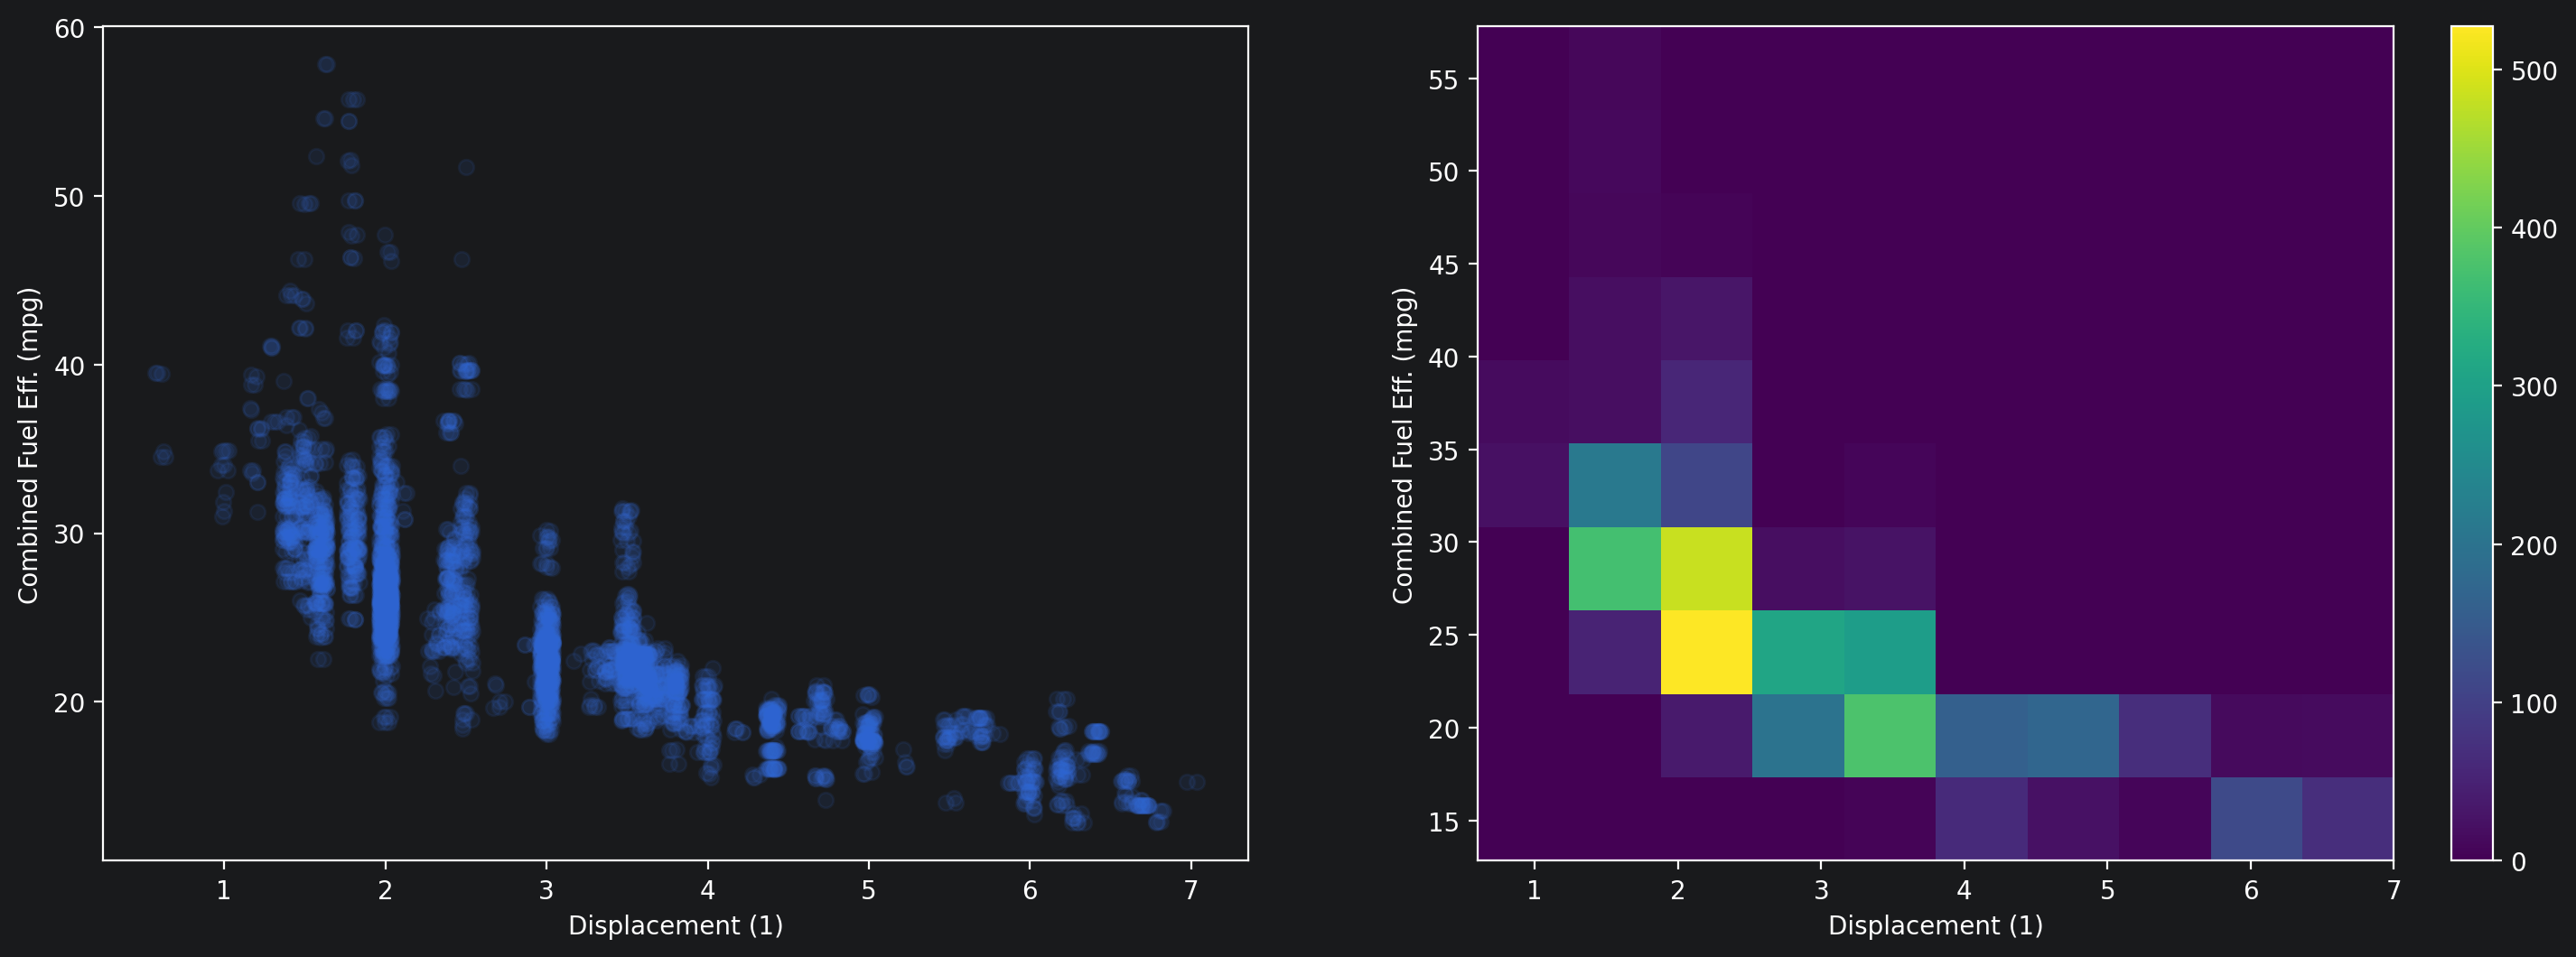

In [10]:
# A heat map is a 2-d version of the histogram
plt.figure(figsize=[18, 6])

plt.subplot(1, 2, 1)
sns.regplot(data=fuel_econ, x='displ', y='comb', x_jitter=0.04, scatter_kws={'alpha': 1 / 10}, fit_reg=False)
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

plt.subplot(1, 2, 2)
plt.hist2d(data=fuel_econ, x='displ', y='comb')
plt.colorbar()
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

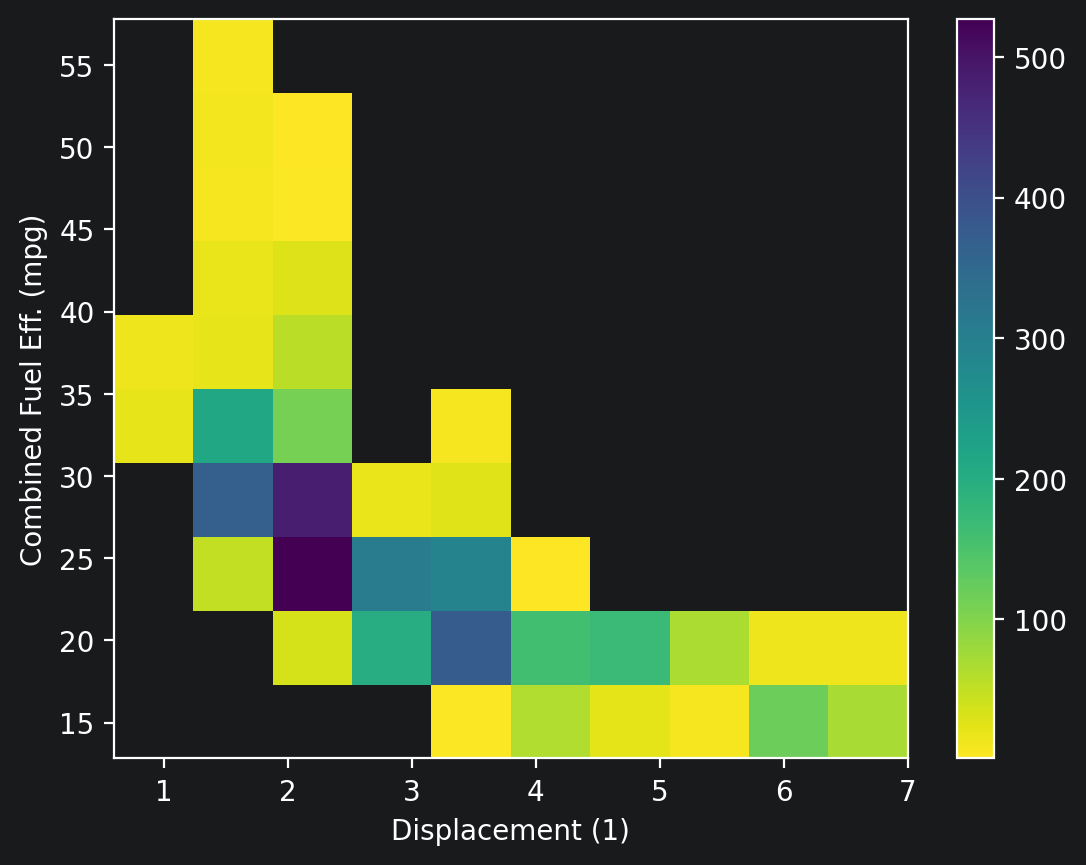

In [11]:
plt.hist2d(data=fuel_econ, x='displ', y='comb', cmin=0.5, cmap='viridis_r')
plt.colorbar()
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

In [12]:
fuel_econ.describe()

,id,year,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
count,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000,3929.000000
mean,36006.724357,2015.500891,5.468313,2.950573,23.660982,59.239247,21.830462,28.044011,29.973842,42.850295,24.791339,376.564266,5.668872,5.659201
std,2189.349923,1.694775,1.878319,1.305901,37.724901,48.667549,6.246273,9.087195,5.747571,9.100423,6.003246,92.338892,1.755860,1.754589
min,32204.000000,2013.000000,2.000000,0.600000,0.000000,0.000000,10.540200,12.900000,16.559400,21.800000,12.821700,29.000000,1.000000,1.000000
25%,34087.000000,2014.000000,4.000000,2.000000,0.000000,0.000000,17.746900,22.200000,25.754200,36.000000,20.658100,315.000000,5.000000,5.000000
50%,36020.000000,2015.000000,5.000000,2.500000,0.000000,91.000000,20.823200,26.400000,29.633800,42.200000,24.000000,369.000000,5.000000,5.000000
75%,37935.000000,2017.000000,6.000000,3.600000,70.000000,100.000000,24.981400,32.264800,33.773100,48.900000,28.227100,429.000000,7.000000,7.000000
max,39901.000000,2018.000000,12.000000,7.000000,102.000000,127.000000,57.808800,83.559800,59.416900,79.100000,57.782400,692.000000,10.000000,10.000000


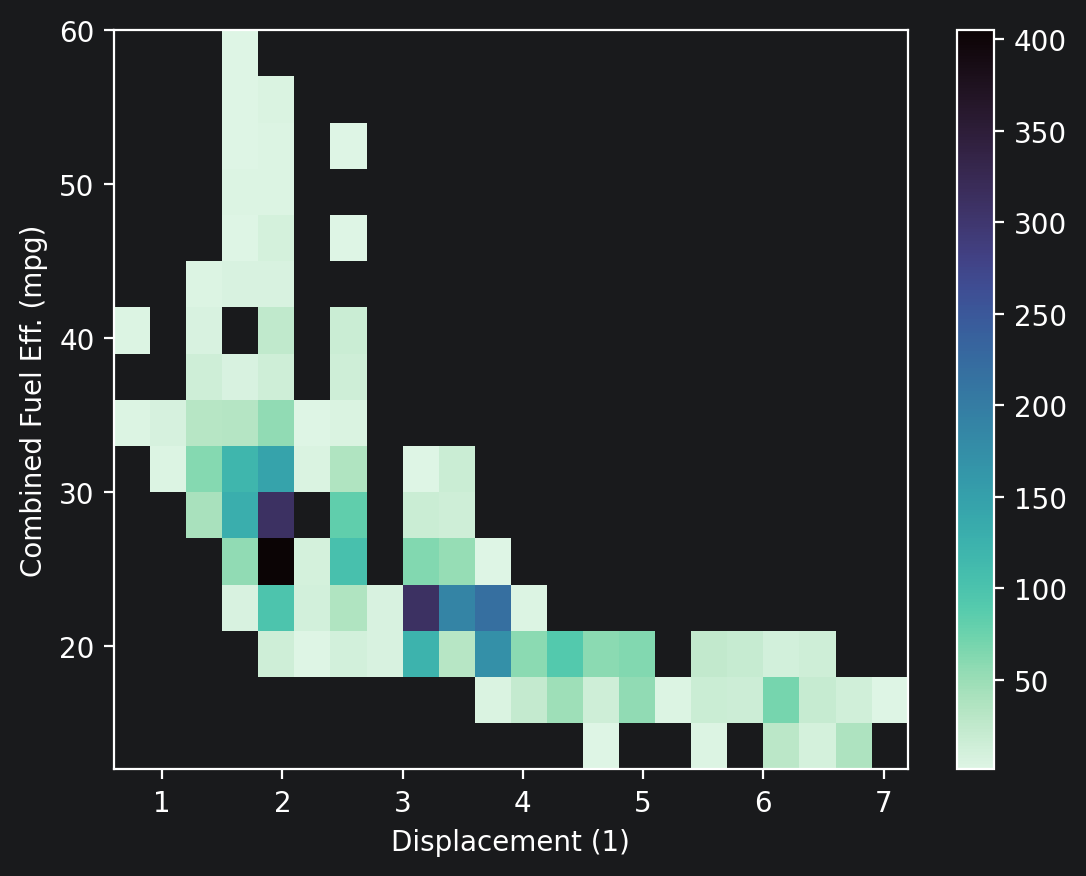

In [13]:
bins_x = np.arange(0.6, 7 + 0.3, 0.3)
bins_y = np.arange(12, 58 + 3, 3)

plt.hist2d(data=fuel_econ, x='displ', y='comb', cmin=0.5, cmap='mako_r', bins=[bins_x, bins_y])
plt.colorbar()
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)');

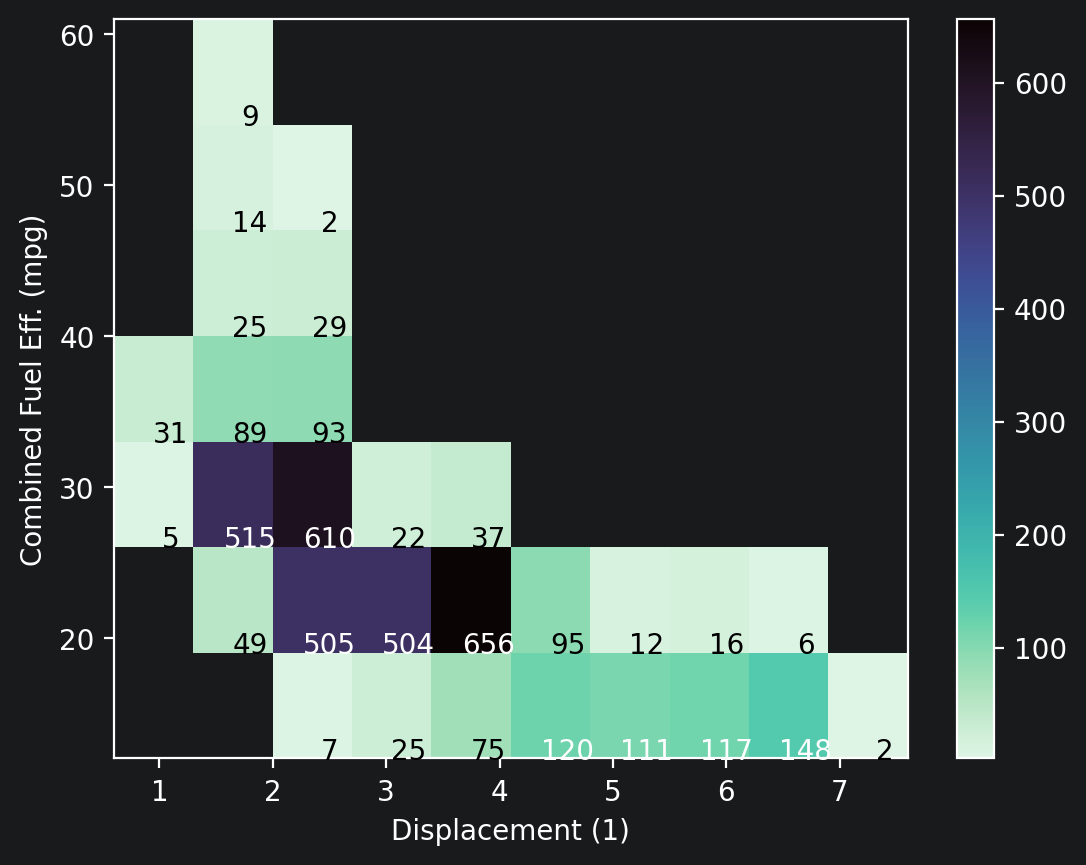

In [14]:
bins_x = np.arange(0.6, 7 + 0.7, 0.7)
bins_y = np.arange(12, 58 + 7, 7)
h2d = plt.hist2d(data=fuel_econ, x='displ', y='comb', cmin=0.5, cmap='mako_r', bins=[bins_x, bins_y])

plt.colorbar()
plt.xlabel('Displacement (1)')
plt.ylabel('Combined Fuel Eff. (mpg)')

counts = h2d[0]

for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        c = counts[i, j]
        if c >= 100:  # increase visibility on darker cells
            plt.text(bins_x[i] + 0.5, bins_y[j] + 0.5, int(c), ha='center', va='center', color='white')
        elif c > 0:
            plt.text(bins_x[i] + 0.5, bins_y[j] + 0.5, int(c), ha='center', va='center', color='black')

### Violin Plots

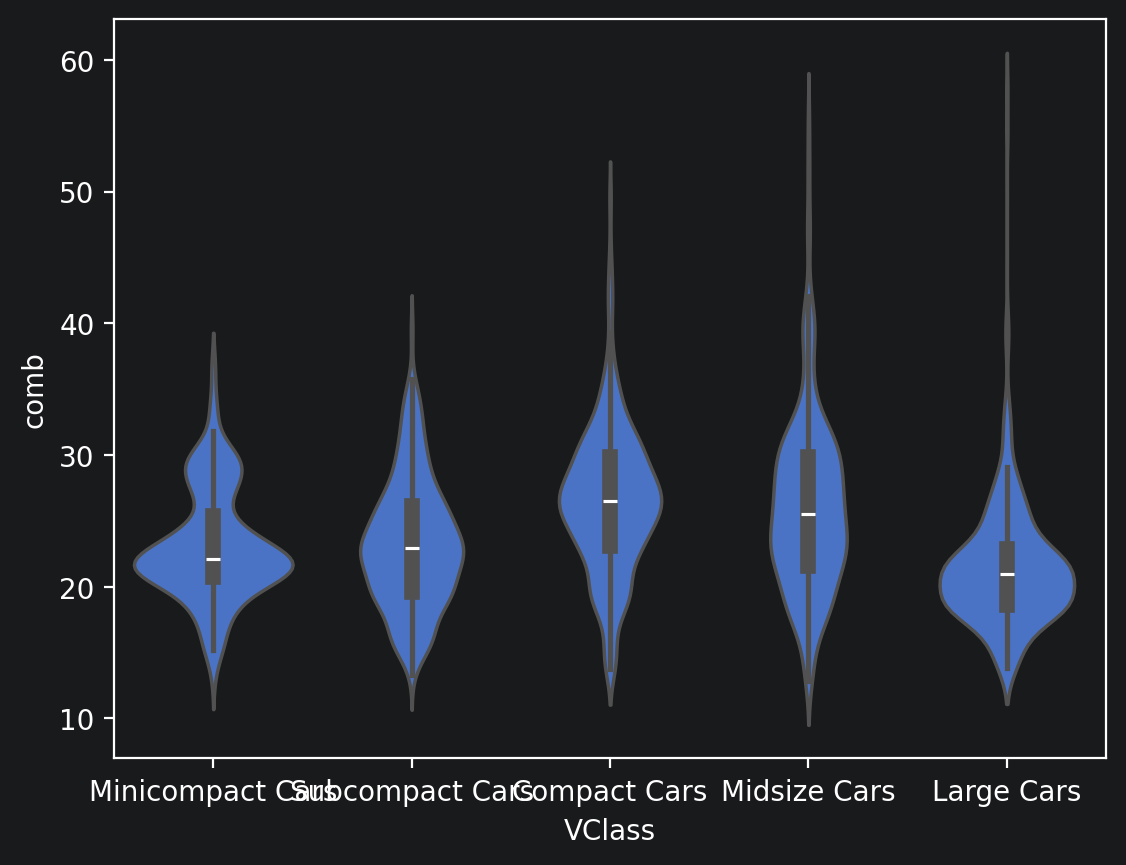

In [15]:
sedan_classes = ['Minicompact Cars', 'Subcompact Cars', 'Compact Cars', 'Midsize Cars', 'Large Cars']

vclasses = pd.api.types.CategoricalDtype(ordered=True, categories=sedan_classes)

fuel_econ['VClass'] = fuel_econ['VClass'].astype(vclasses)

sns.violinplot(data=fuel_econ, x='VClass', y='comb');

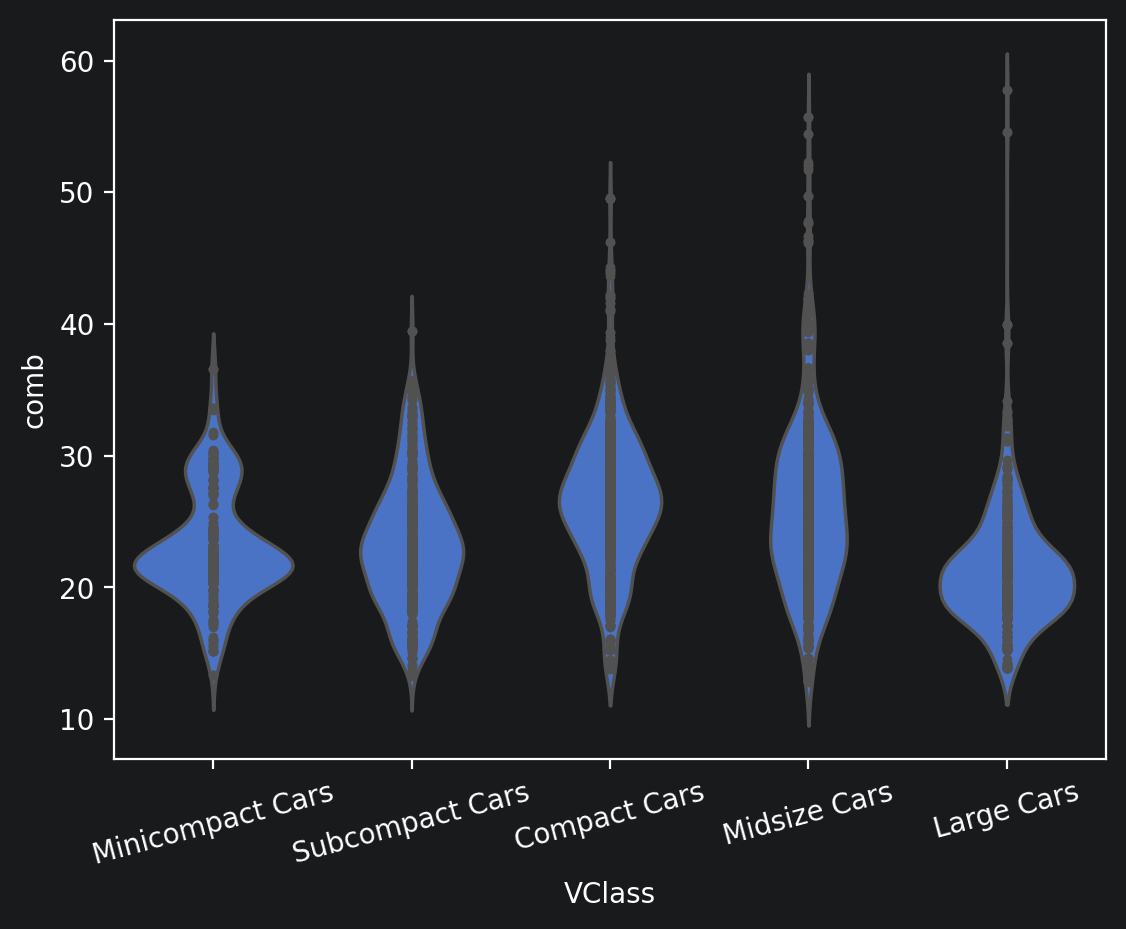

In [16]:
base_color = sns.color_palette()[0]
# inner can take any value from {﷿﷿﷿box﷿﷿﷿, ﷿﷿﷿quartile﷿﷿﷿, ﷿﷿﷿point﷿﷿﷿, ﷿﷿﷿stick﷿﷿﷿, None}
sns.violinplot(data=fuel_econ, x='VClass', y='comb', color=base_color, inner='point')
plt.xticks(rotation=15);

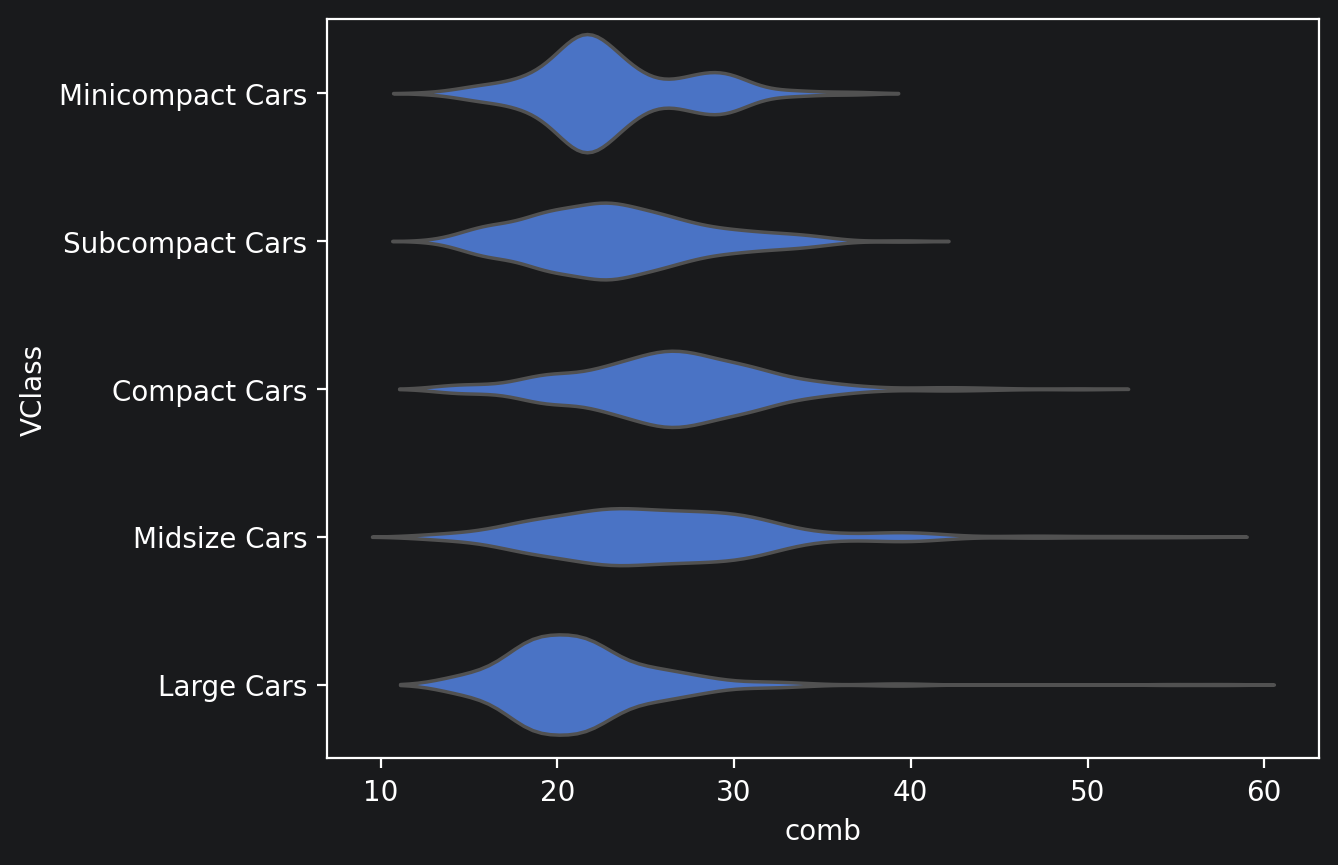

In [17]:
sns.violinplot(data=fuel_econ, y='VClass', x='comb', color=base_color, inner=None);

### Box Plots

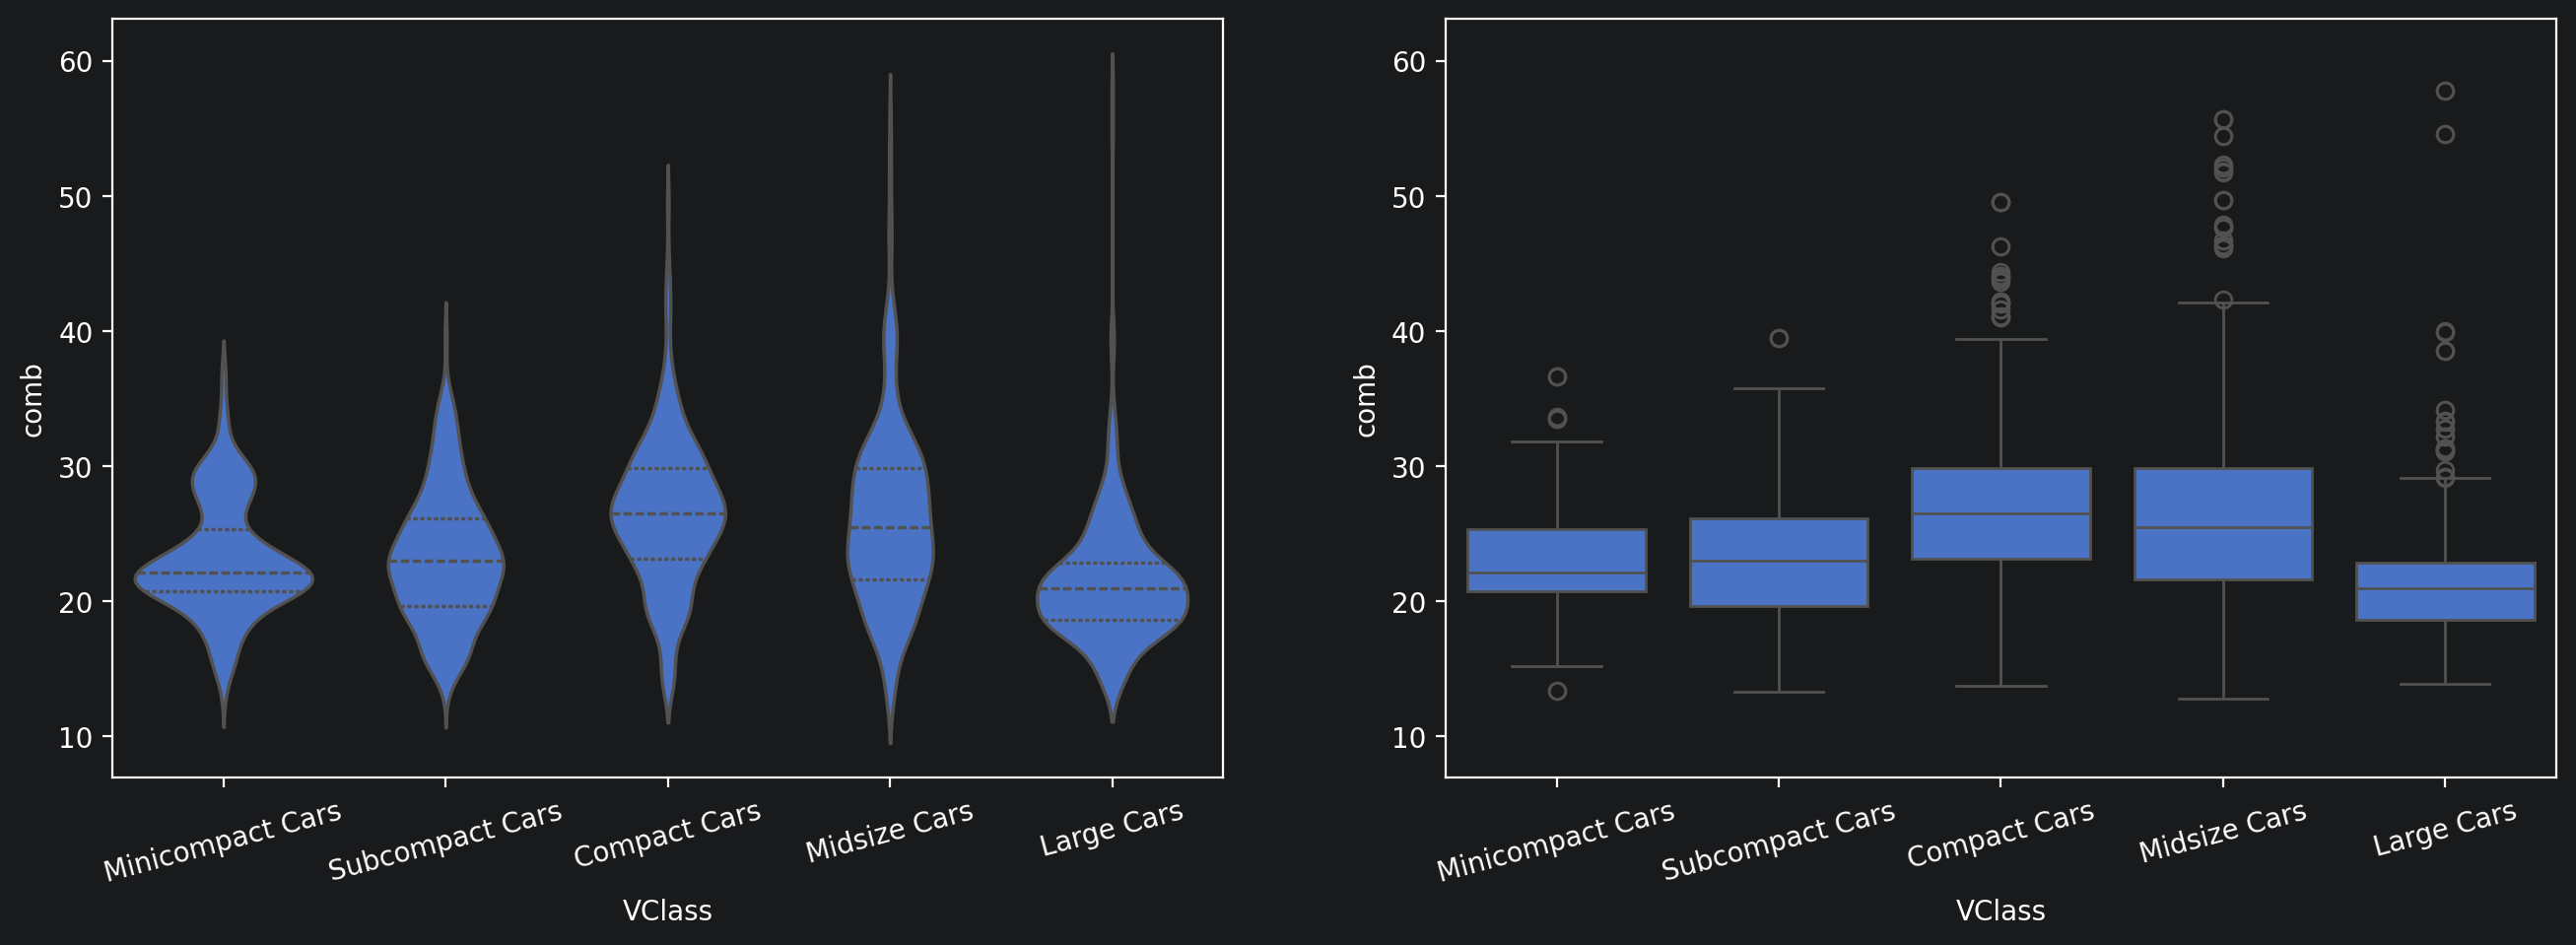

In [18]:
sedan_classes = ['Minicompact Cars', 'Subcompact Cars', 'Compact Cars', 'Midsize Cars', 'Large Cars']
vclasses = pd.api.types.CategoricalDtype(ordered=True, categories=sedan_classes)

# Use pandas.astype() to convert the "VClass" column from a plain object type into an ordered categorical type
fuel_econ['VClass'] = fuel_econ['VClass'].astype(vclasses)

plt.figure(figsize=[16, 5])
base_color = sns.color_palette()[0]

plt.subplot(1, 2, 1)
ax1 = sns.violinplot(data=fuel_econ, x='VClass', y='comb', color=base_color, inner='quartile')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.boxplot(data=fuel_econ, x='VClass', y='comb', color=base_color)
plt.xticks(rotation=15)
plt.ylim(ax1.get_ylim());  # set y-axis limits to be same as left plot

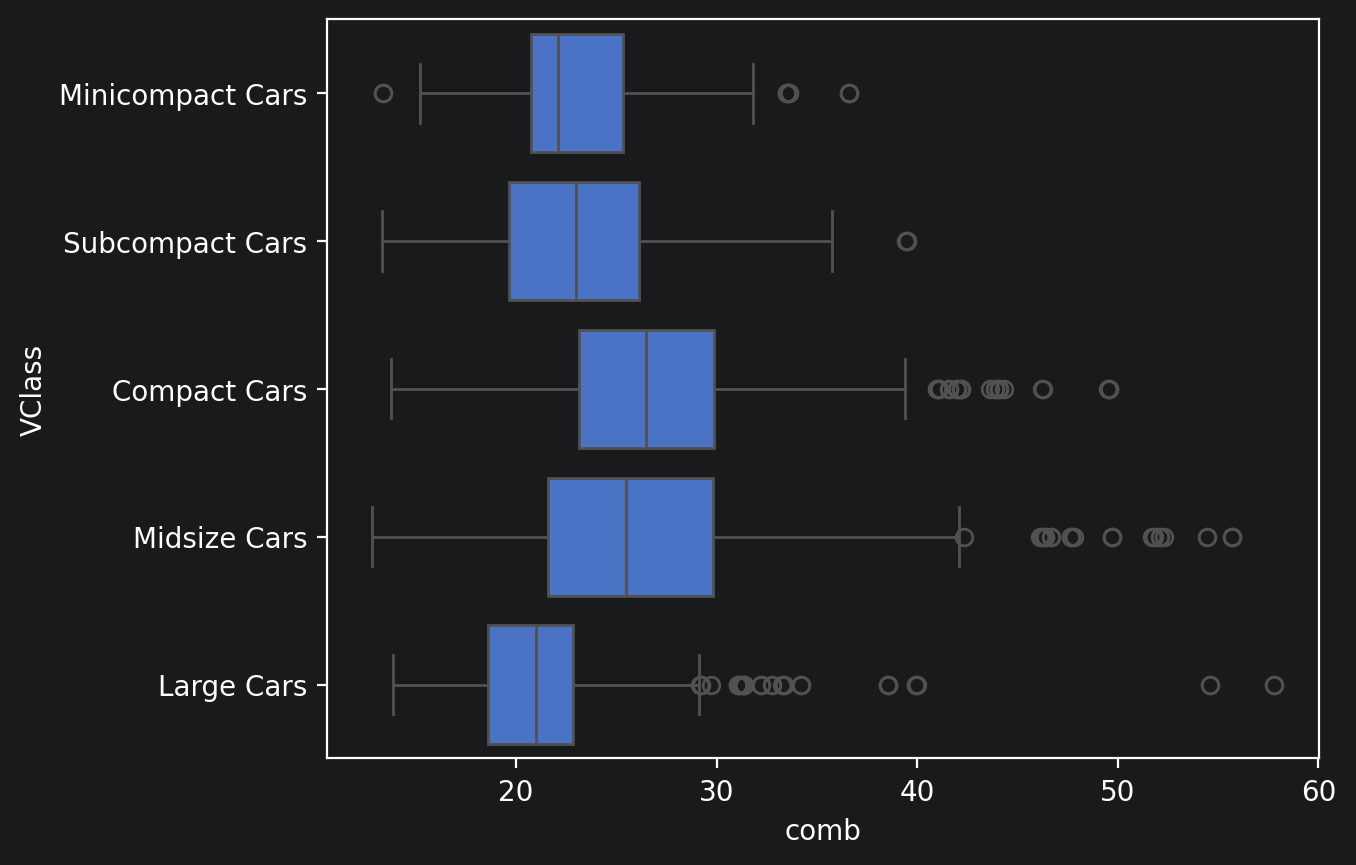

In [19]:
sns.boxplot(data=fuel_econ, y='VClass', x='comb', color=base_color);

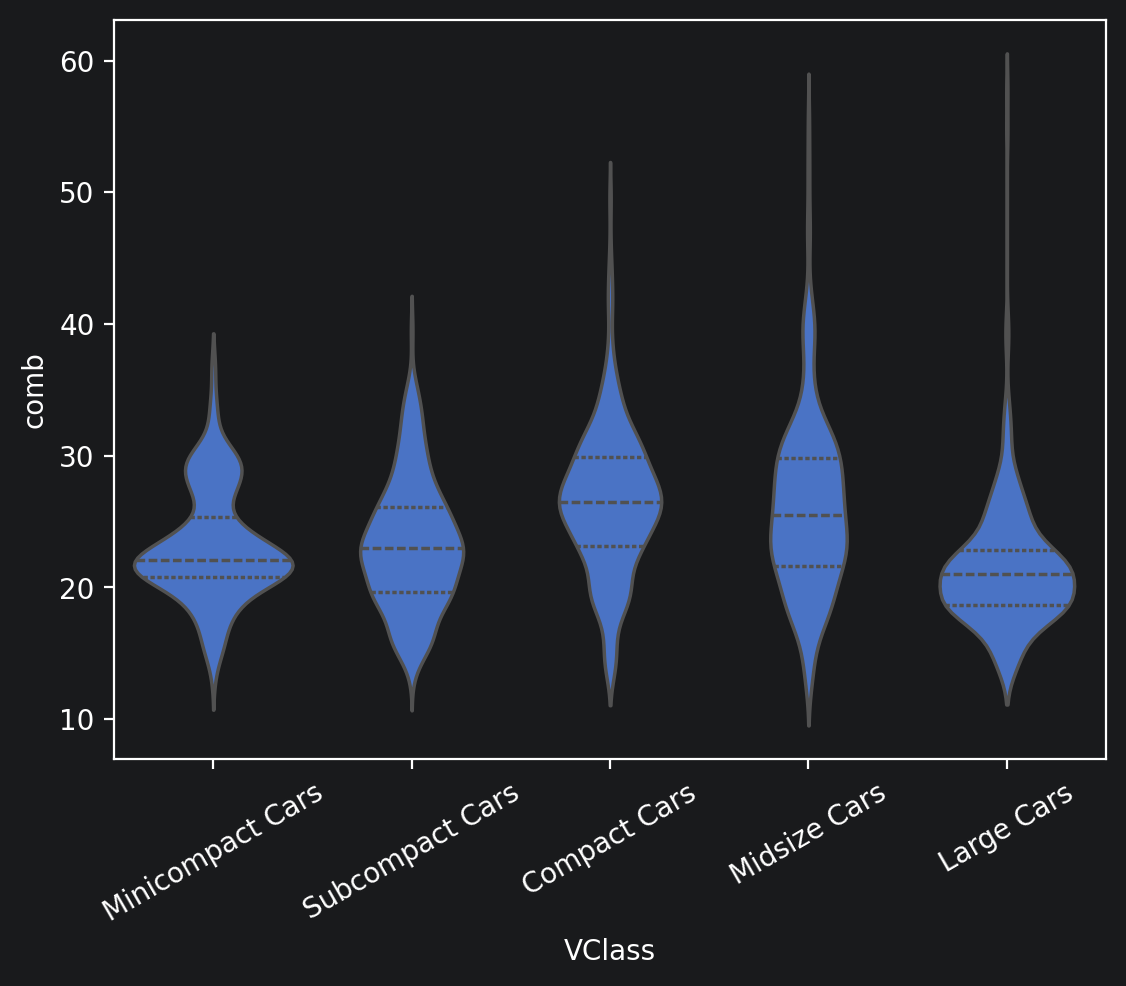

In [20]:
base_color = sns.color_palette()[0]
sns.violinplot(data=fuel_econ, x='VClass', y='comb', color=base_color, inner='quartile')
plt.xticks(rotation=30);

### Clustered Bar Charts

In [21]:
sedan_classes = ['Minicompact Cars', 'Subcompact Cars', 'Compact Cars', 'Midsize Cars', 'Large Cars']
vclasses = pd.api.types.CategoricalDtype(ordered=True, categories=sedan_classes)
fuel_econ['VClass'] = fuel_econ['VClass'].astype(vclasses);

In [22]:
fuel_econ['trans_type'] = fuel_econ['trans'].apply(lambda x: x.split()[0])
fuel_econ.head()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,...,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore,trans_type
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,...,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4,Automatic
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,...,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6,Automatic
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,...,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5,Automatic
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,...,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5,Automatic
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,...,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8,Automatic


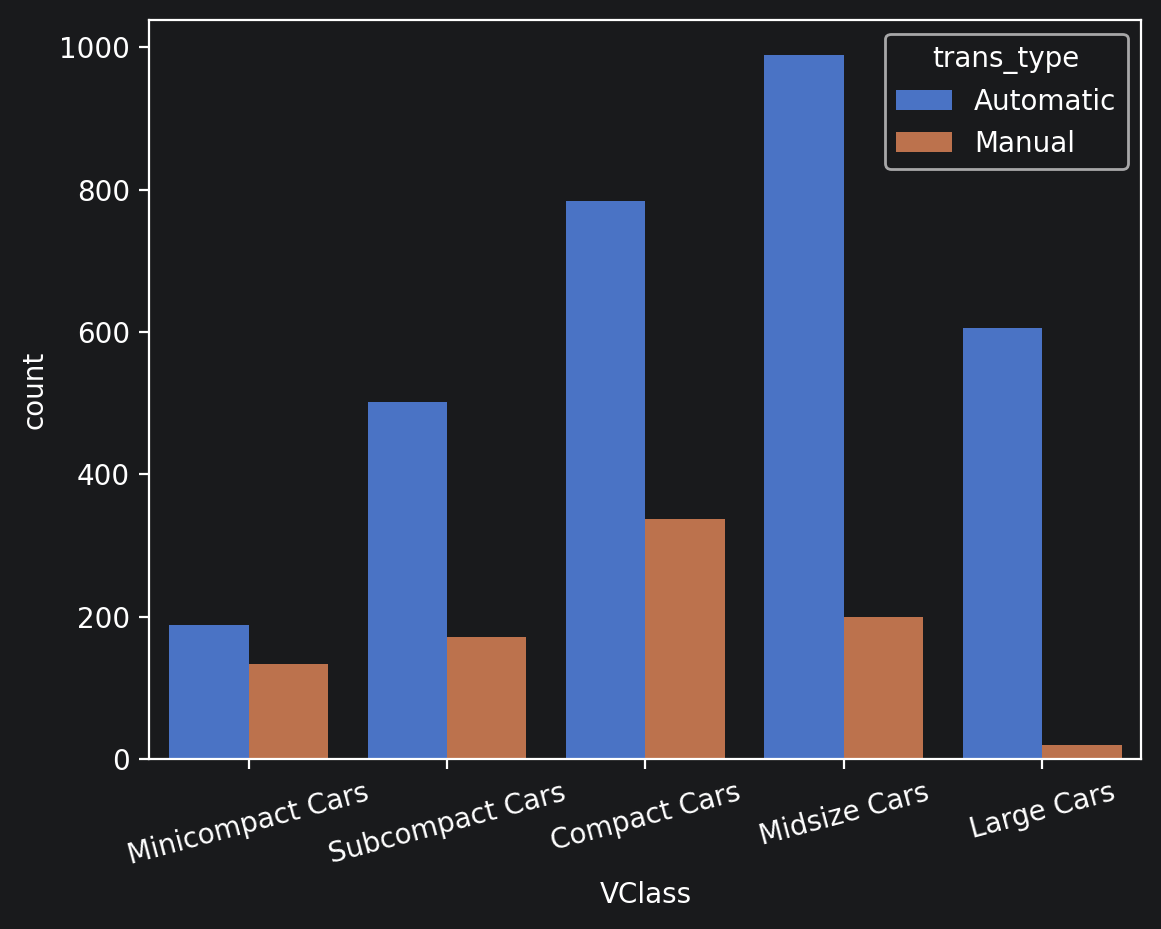

In [23]:
sns.countplot(data=fuel_econ, x='VClass', hue='trans_type')
plt.xticks(rotation=15);

In [24]:
ct_counts = fuel_econ.groupby(['VClass', 'trans_type'], observed=True).size()
ct_counts

VClass            trans_type
Minicompact Cars  Automatic     188
                  Manual        133
Subcompact Cars   Automatic     502
                  Manual        171
Compact Cars      Automatic     784
                  Manual        338
Midsize Cars      Automatic     989
                  Manual        199
Large Cars        Automatic     605
                  Manual         20
dtype: int64

In [25]:
ct_counts = ct_counts.reset_index(name='count')
ct_counts

,VClass,trans_type,count
0,Minicompact Cars,Automatic,188
1,Minicompact Cars,Manual,133
2,Subcompact Cars,Automatic,502
3,Subcompact Cars,Manual,171
4,Compact Cars,Automatic,784
5,Compact Cars,Manual,338
6,Midsize Cars,Automatic,989
7,Midsize Cars,Manual,199
8,Large Cars,Automatic,605
9,Large Cars,Manual,20


In [26]:
ct_counts = ct_counts.pivot(index='VClass', columns='trans_type', values='count')
ct_counts

trans_type,Automatic,Manual
VClass,,
Minicompact Cars,188,133
Subcompact Cars,502,171
Compact Cars,784,338
Midsize Cars,989,199
Large Cars,605,20


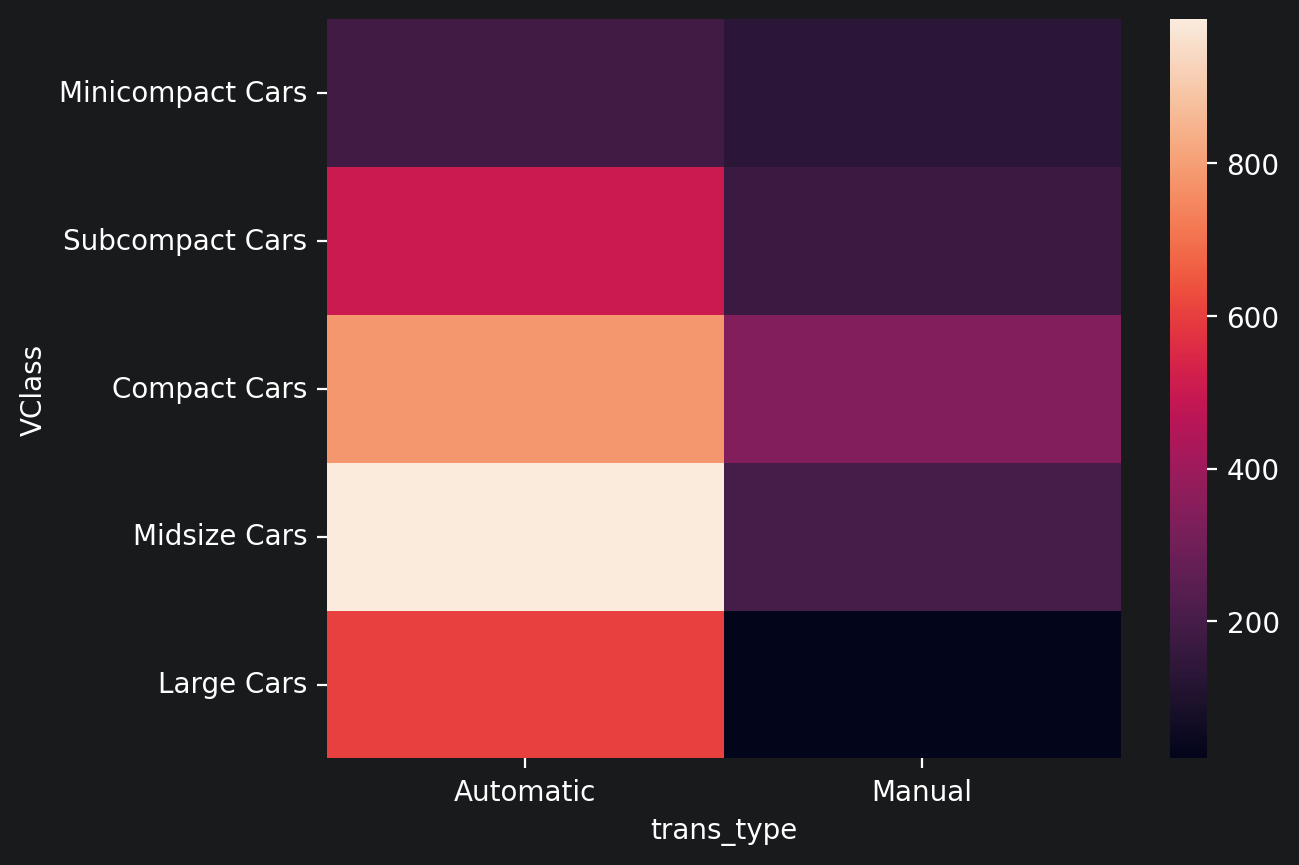

In [27]:
sns.heatmap(ct_counts);

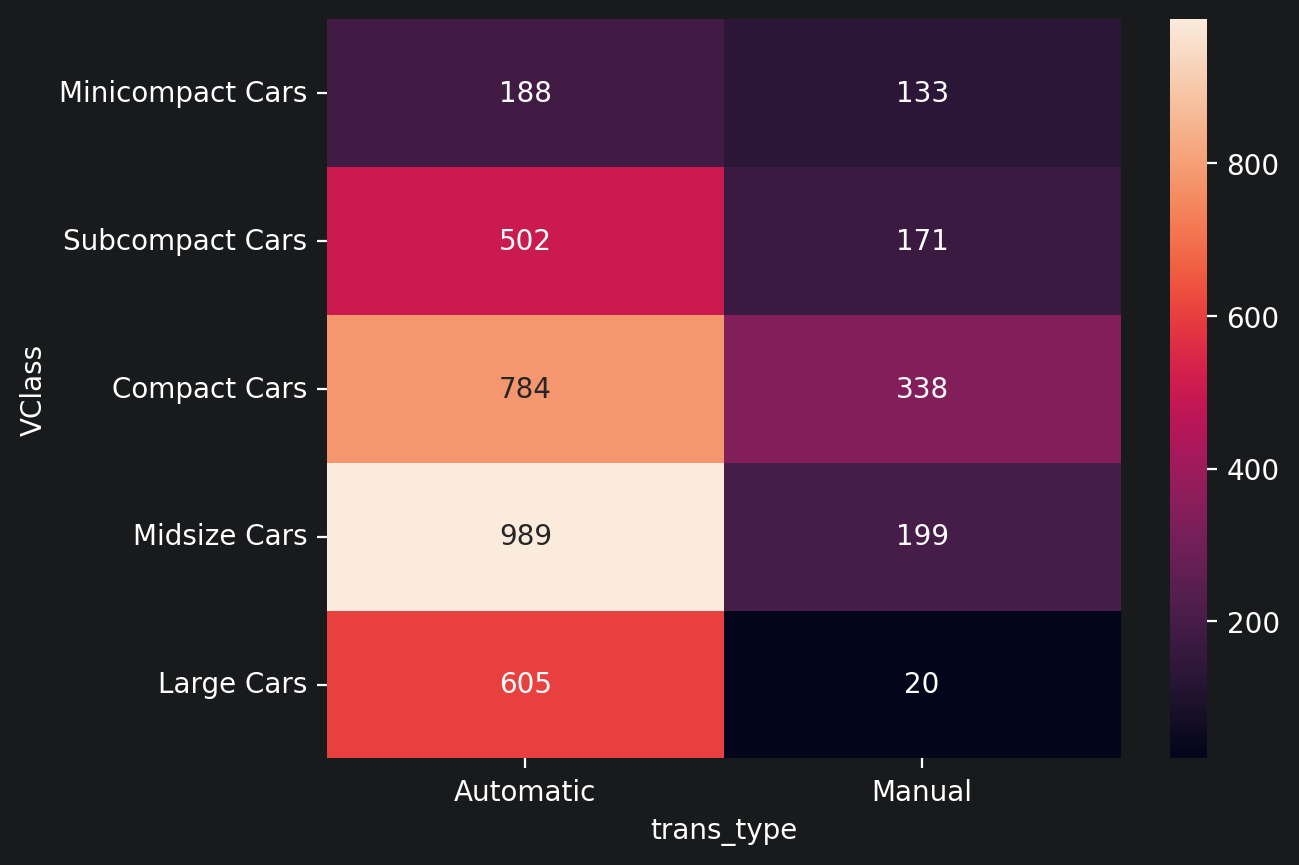

In [28]:
sns.heatmap(ct_counts, annot=True, fmt='d');

### Faceting

In [29]:
# In faceting, the data is divided into disjoint subsets, most often by different levels of a categorical variable. For each of these subsets of the data, the same plot type is rendered on other variables. Faceting is a way of comparing distributions or relationships across levels of additional variables, especially when there are three or more variables of interest overall.

In [30]:
# make sure use the same axis proportions sharey=False -> True

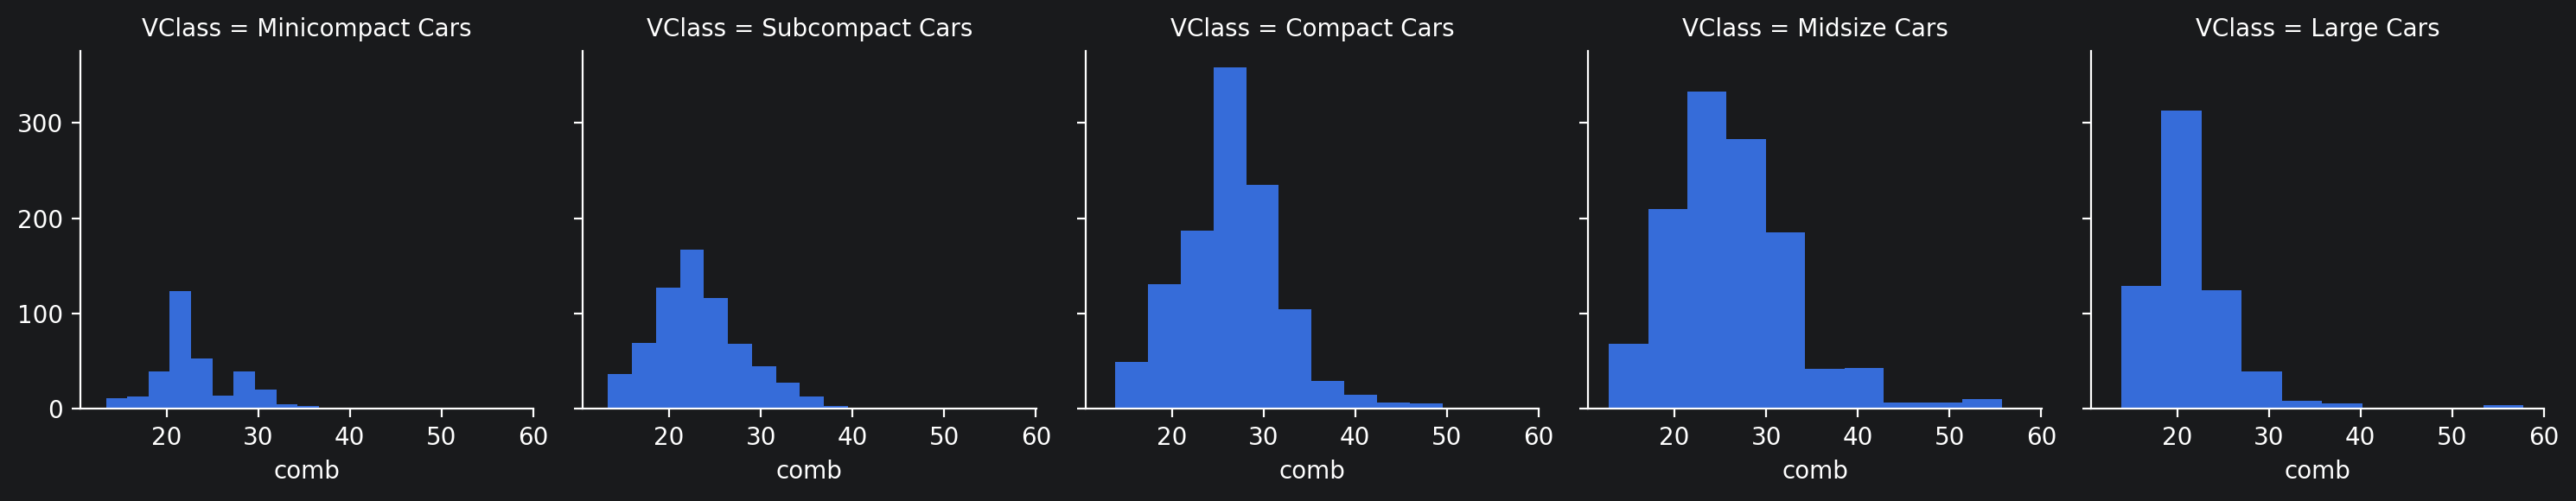

In [31]:
sedan_classes = ['Minicompact Cars', 'Subcompact Cars', 'Compact Cars', 'Midsize Cars', 'Large Cars']
vclasses = pd.api.types.CategoricalDtype(ordered=True, categories=sedan_classes)
fuel_econ['VClass'] = fuel_econ['VClass'].astype(vclasses)

g = sns.FacetGrid(data=fuel_econ, col='VClass')
g.map(plt.hist, "comb");

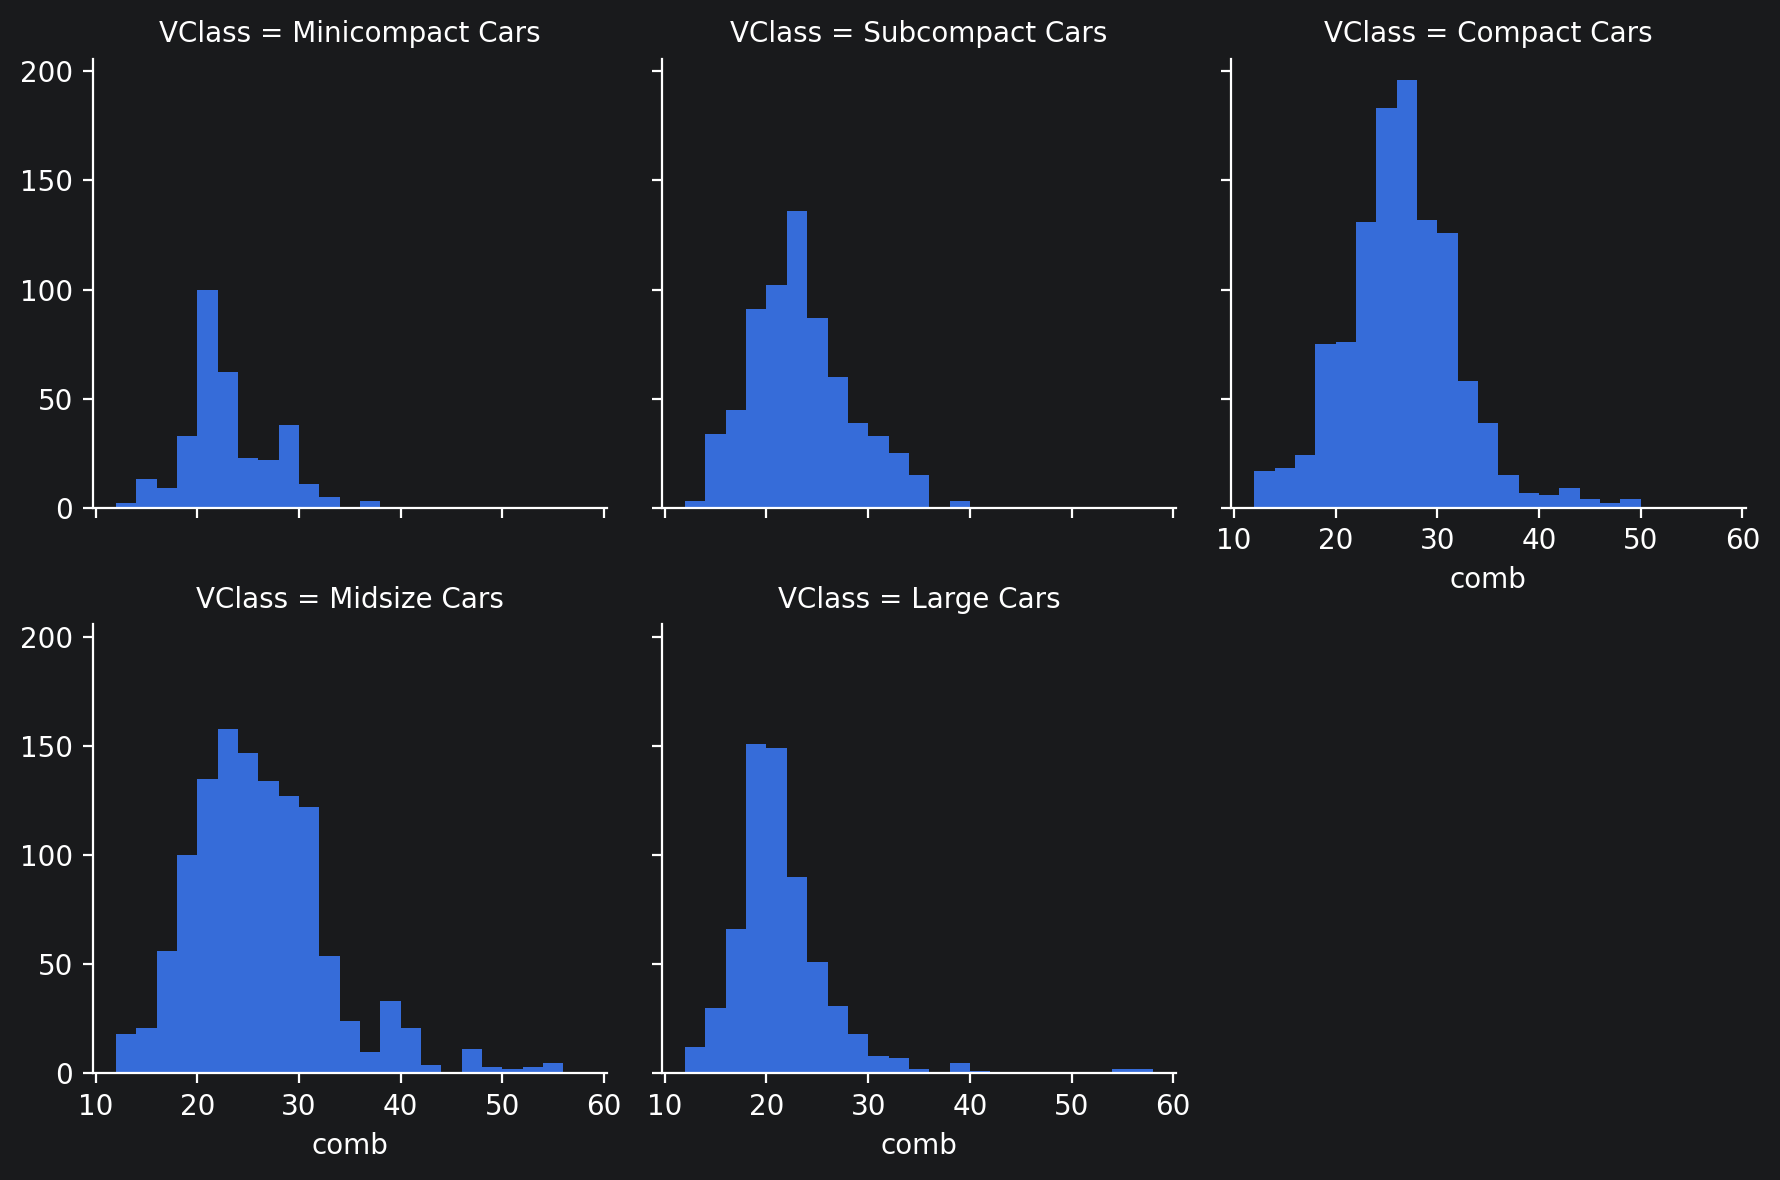

In [32]:
bin_edges = np.arange(12, 58 + 2, 2)

# Try experimenting with dynamic bin edges
# bin_edges = np.arange(-3, fuel_econ['comb'].max()+1/3, 1/3)

g = sns.FacetGrid(data=fuel_econ, col='VClass', col_wrap=3, sharey=True)
g.map(plt.hist, 'comb', bins=bin_edges);

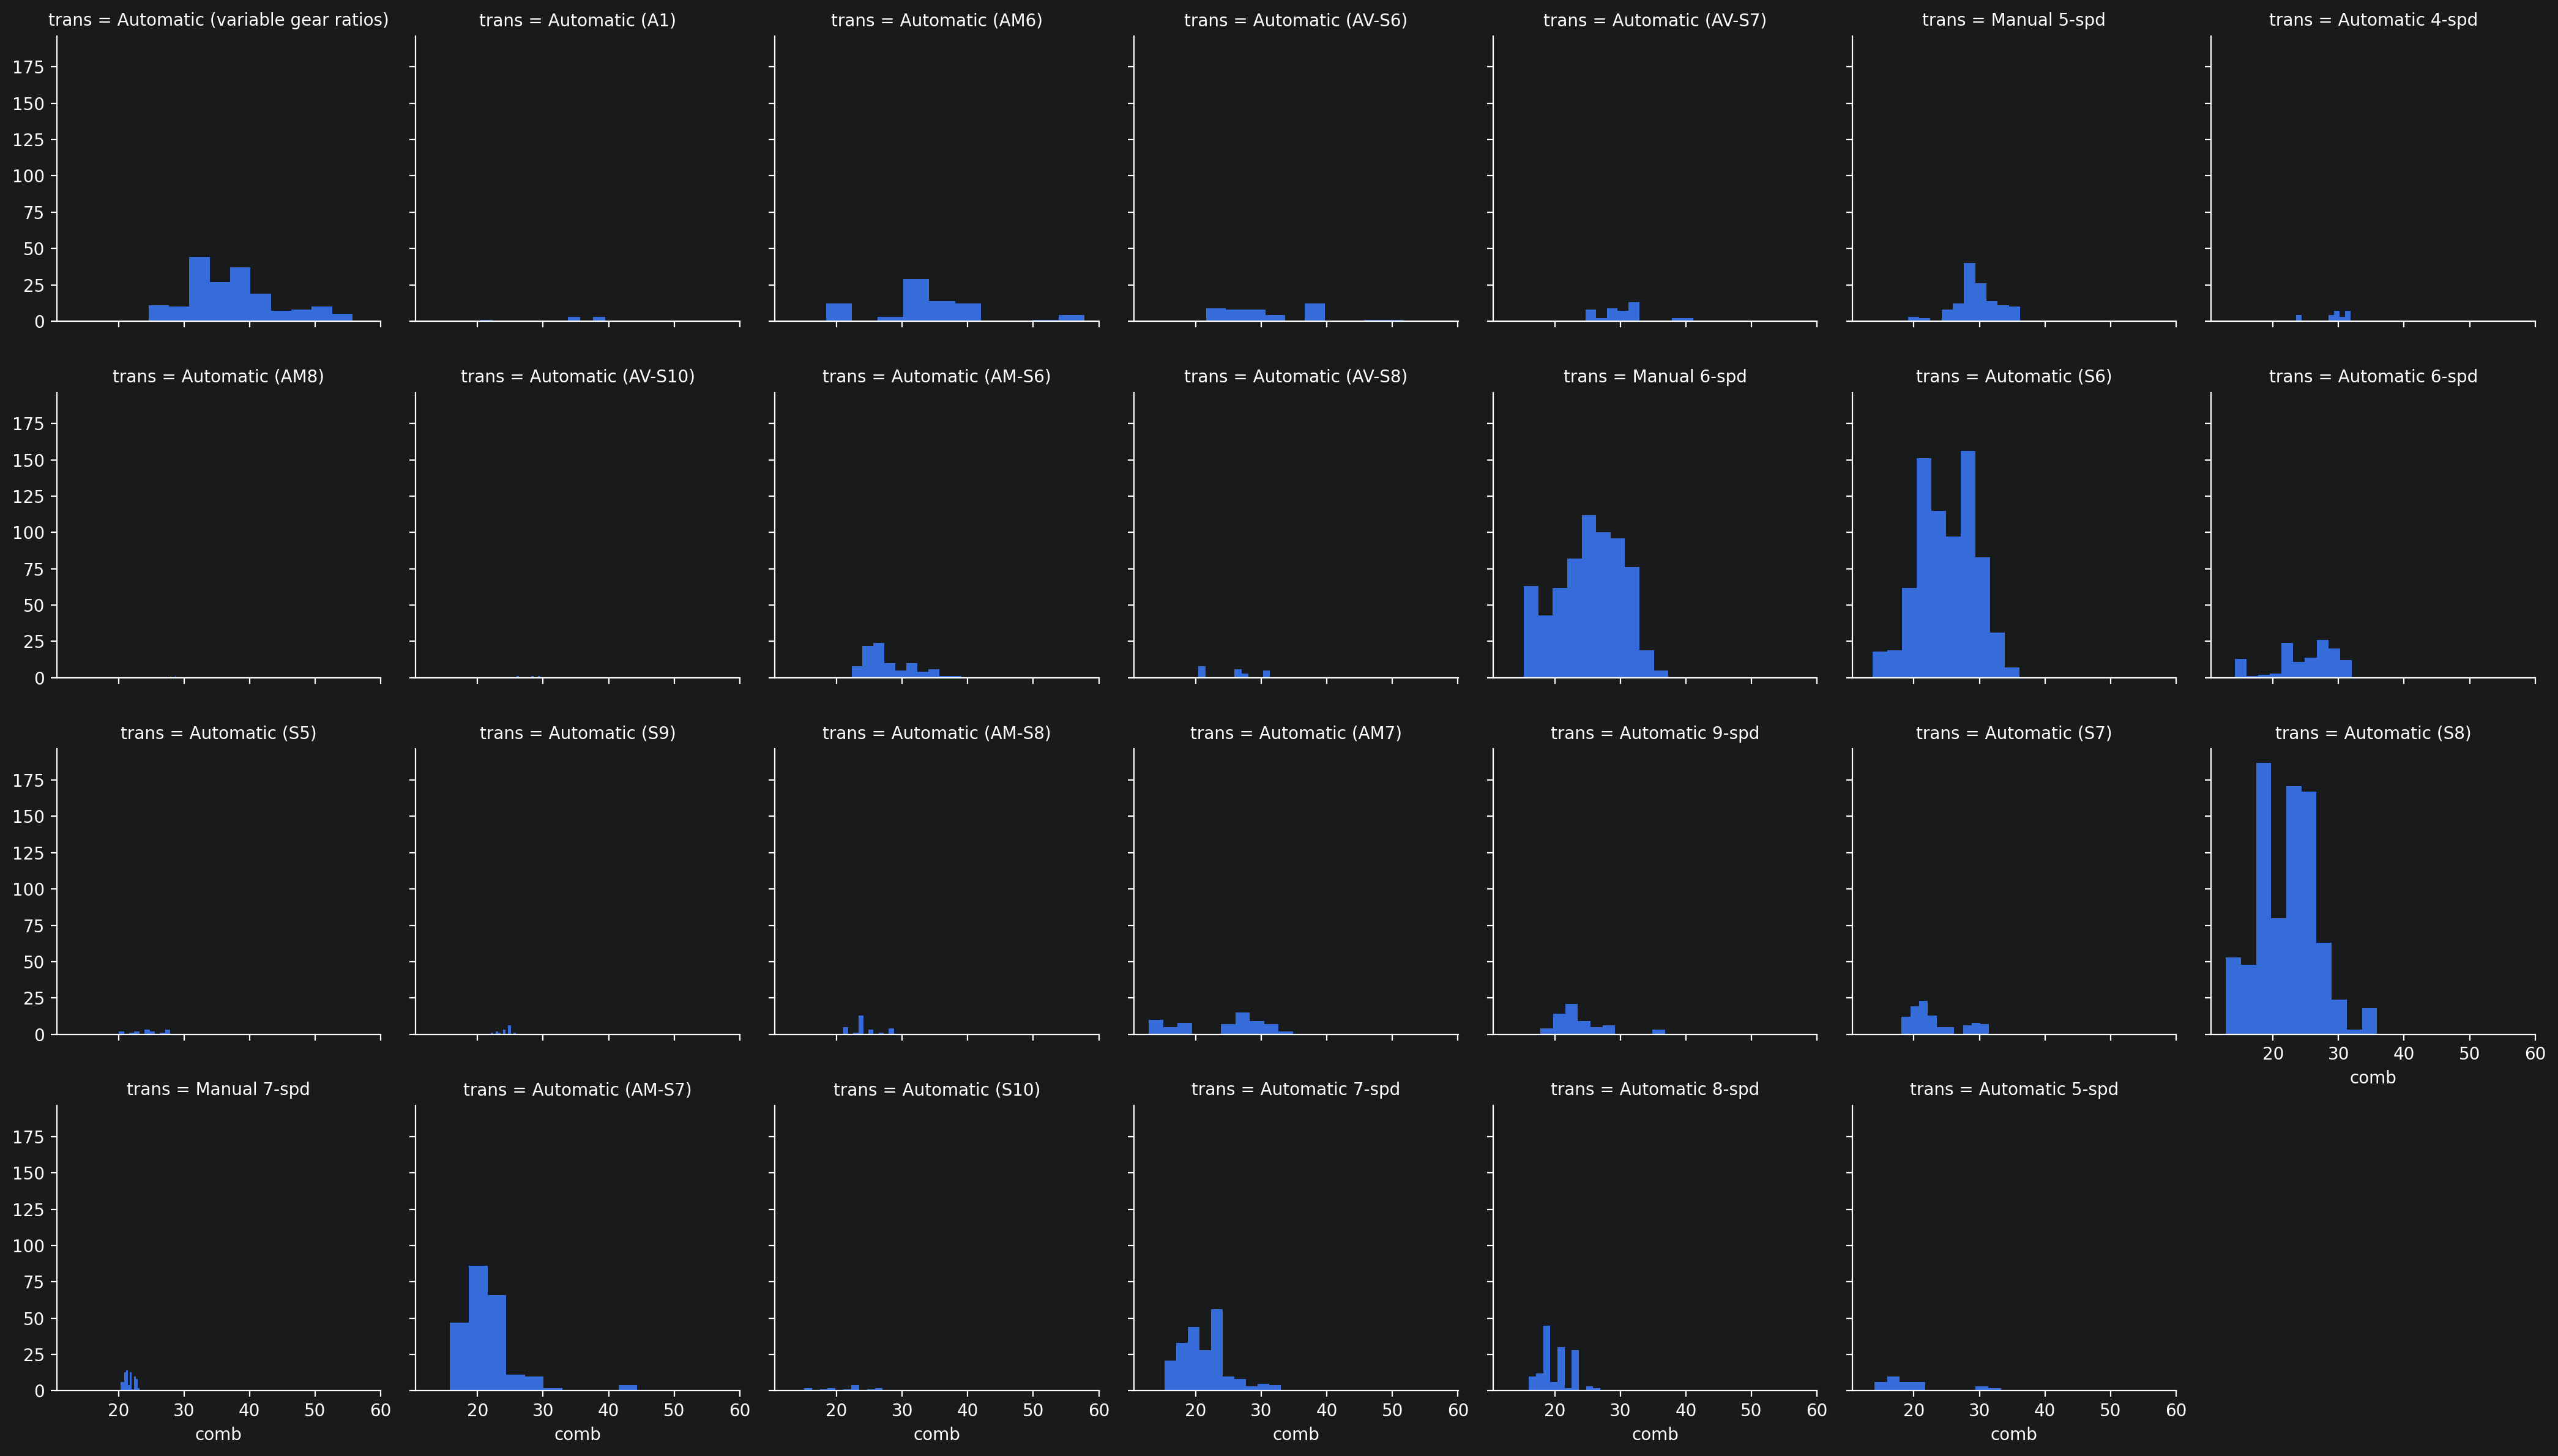

In [33]:
group_means = fuel_econ[['trans', 'comb']].groupby(['trans']).mean()
group_order = group_means.sort_values(['comb'], ascending=False).index

g = sns.FacetGrid(data=fuel_econ, col='trans', col_wrap=7, col_order=group_order)
g.map(plt.hist, 'comb');

### Adaptation of Univariate Plots

In [34]:
# These plots can be adapted for use as bivariate plots by, instead of indicating count by height, indicating a mean or other statistic on a second variable

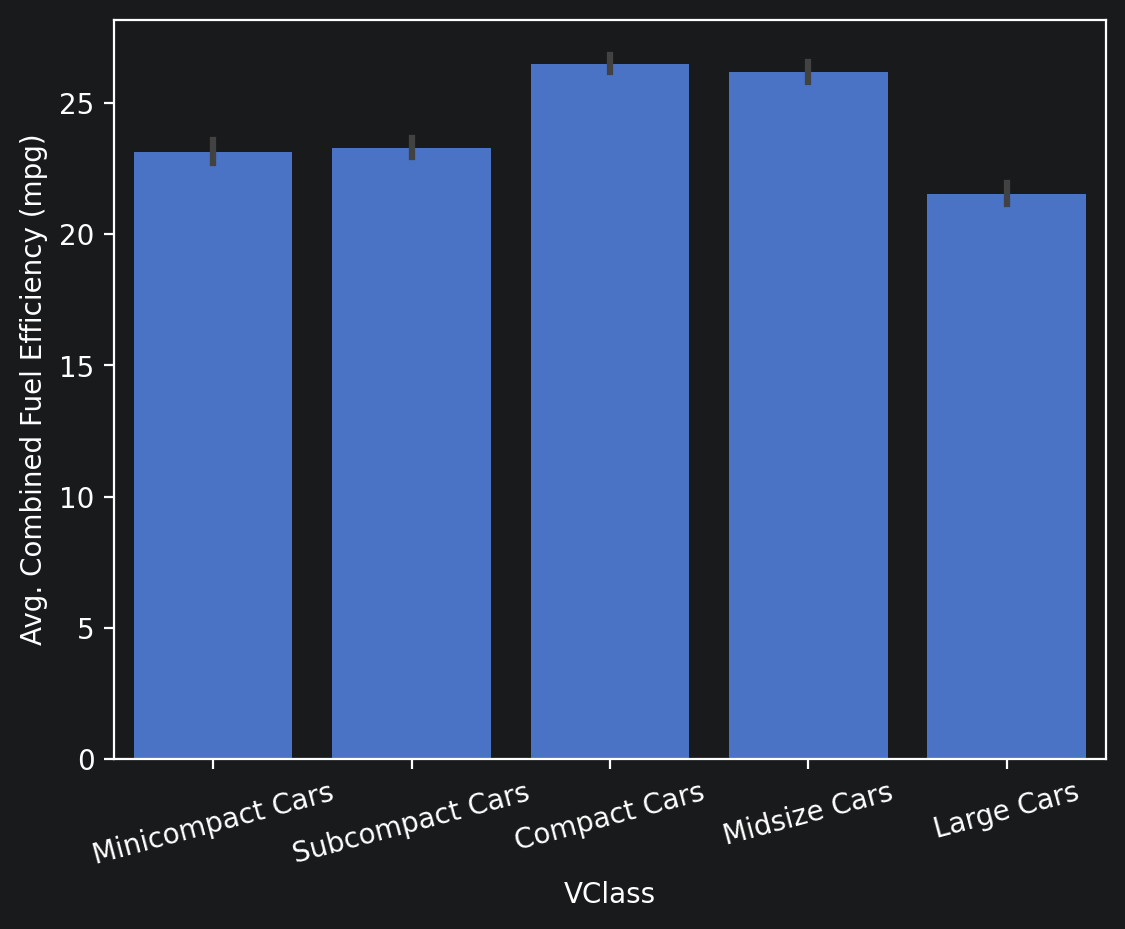

In [35]:
base_color = sns.color_palette()[0]
sns.barplot(data=fuel_econ, x='VClass', y='comb', color=base_color)
plt.xticks(rotation=15)
plt.ylabel('Avg. Combined Fuel Efficiency (mpg)');

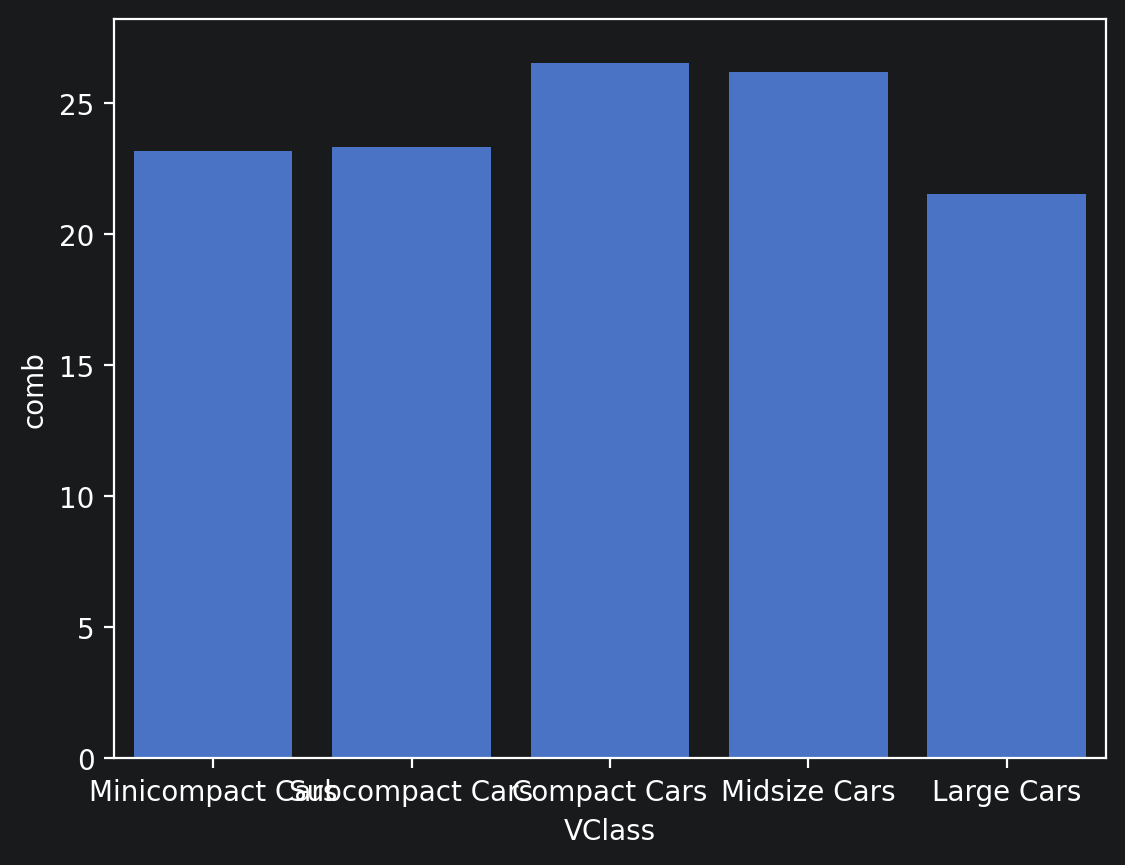

In [36]:
sns.barplot(data=fuel_econ, x='VClass', y='comb', color=base_color, err_kws={'linewidth': 0});

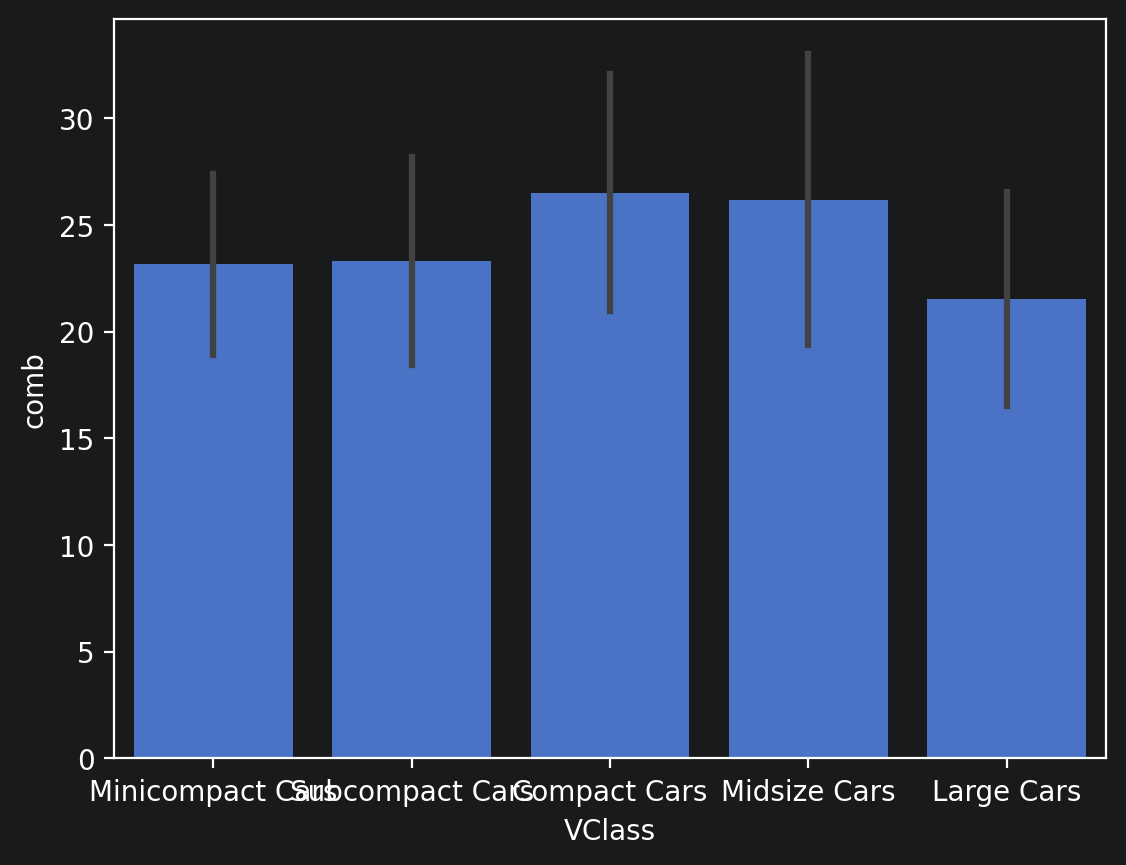

In [37]:
sns.barplot(data=fuel_econ, x='VClass', y='comb', color=base_color, errorbar='sd');

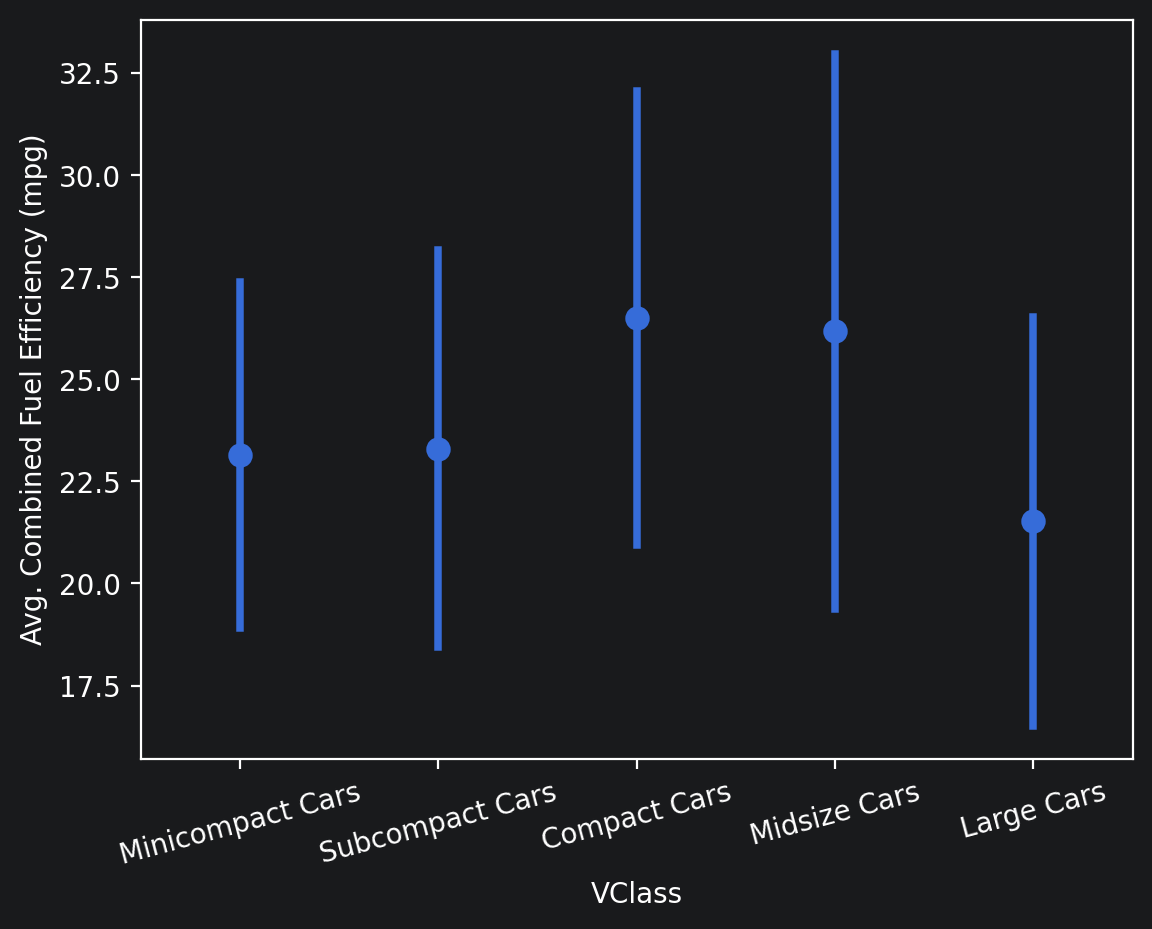

In [38]:
sns.pointplot(data=fuel_econ, x='VClass', y='comb', color=base_color, errorbar='sd', linestyles='')
plt.xticks(rotation=15)
plt.ylabel('Avg. Combined Fuel Efficiency (mpg)');

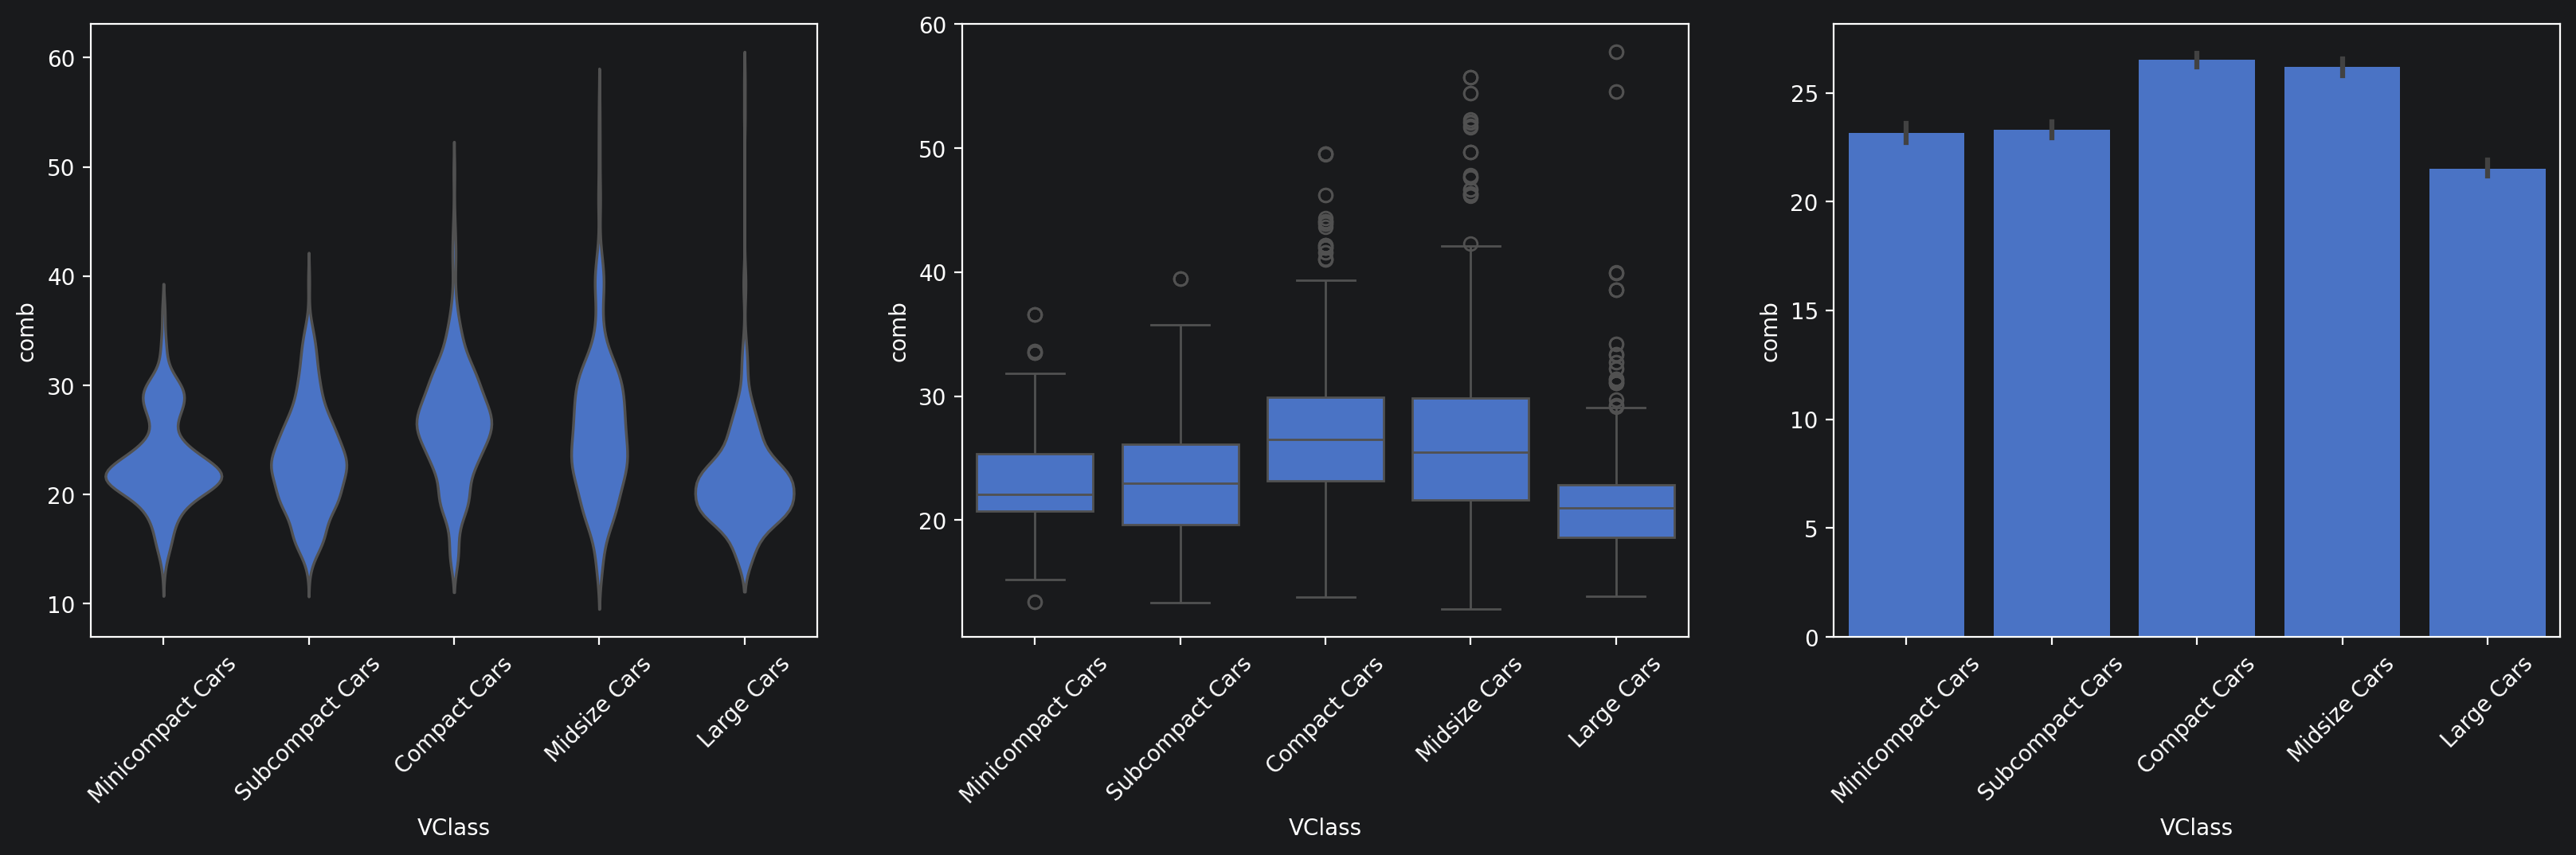

In [39]:
plt.figure(figsize=[20, 5])
base_color = sns.color_palette()[0]

plt.subplot(1, 3, 1)
sns.violinplot(data=fuel_econ, x='VClass', y='comb', inner=None, color=base_color)
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=fuel_econ, x='VClass', y='comb', color=base_color)
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.barplot(data=fuel_econ, x='VClass', y='comb', color=base_color)
plt.xticks(rotation=45);

### Line Plots

In [40]:
# In a line plot, only one point is plotted for every unique x-value or bin of x-values (like a histogram)
# If there are multiple observations in an x-bin, then the y-value of the point plotted in the line plot will be a summary statistic (like mean or median) of the data in the bin

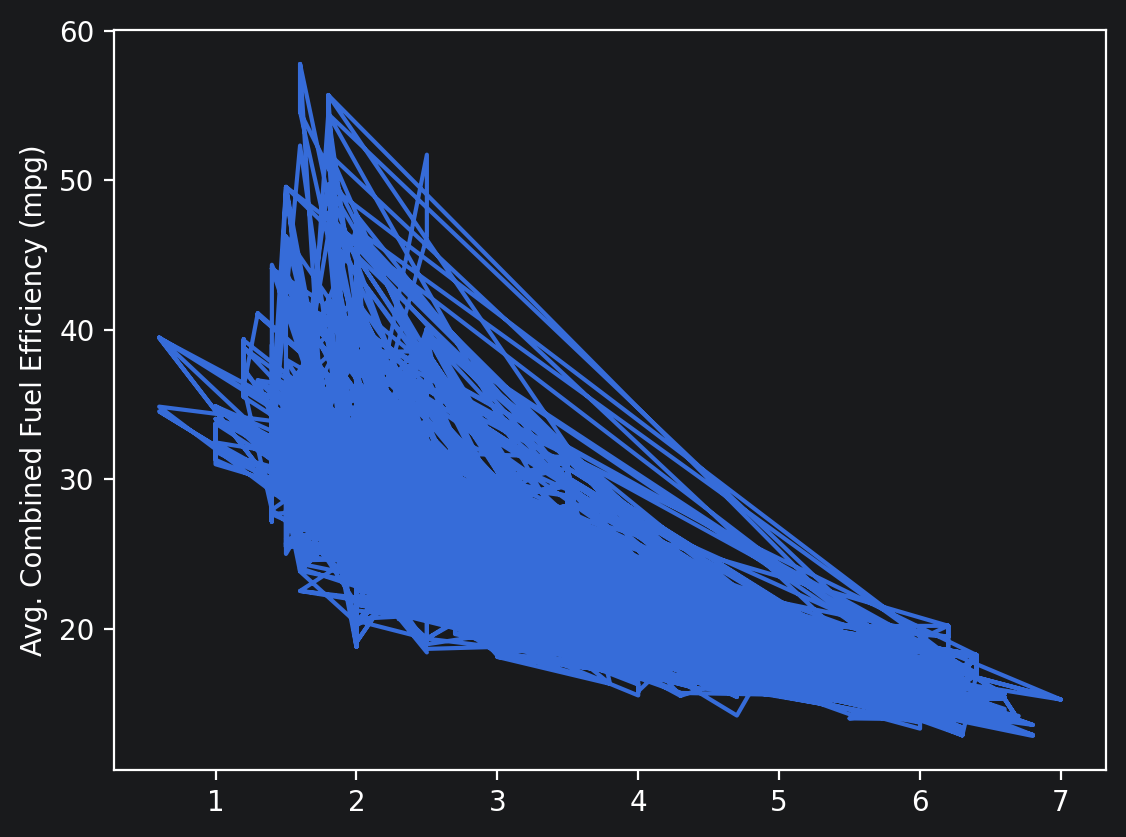

In [41]:
plt.errorbar(data=fuel_econ, x='displ', y='comb')
plt.ylabel('Avg. Combined Fuel Efficiency (mpg)');

In [42]:
bin_edges = np.arange(0.6, 7 + 0.2, 0.2)
bin_centers = bin_edges[:-1] + 0.1
displ_binned = pd.cut(fuel_econ['displ'], bin_edges, include_lowest=True)
displ_binned

0       (3.6, 3.8]
1       (1.8, 2.0]
2       (3.4, 3.6]
3       (3.4, 3.6]
4       (2.2, 2.4]
           ...    
3924    (1.6, 1.8]
3925    (1.8, 2.0]
3926    (1.8, 2.0]
3927    (3.2, 3.4]
3928    (3.2, 3.4]
Name: displ, Length: 3929, dtype: category
Categories (32, interval[float64, right]): [(0.599, 0.8] < (0.8, 1.0] < (1.0, 1.2] < (1.2, 1.4] ... (6.2, 6.4] < (6.4, 6.6] < (6.6, 6.8] < (6.8, 7.0]]

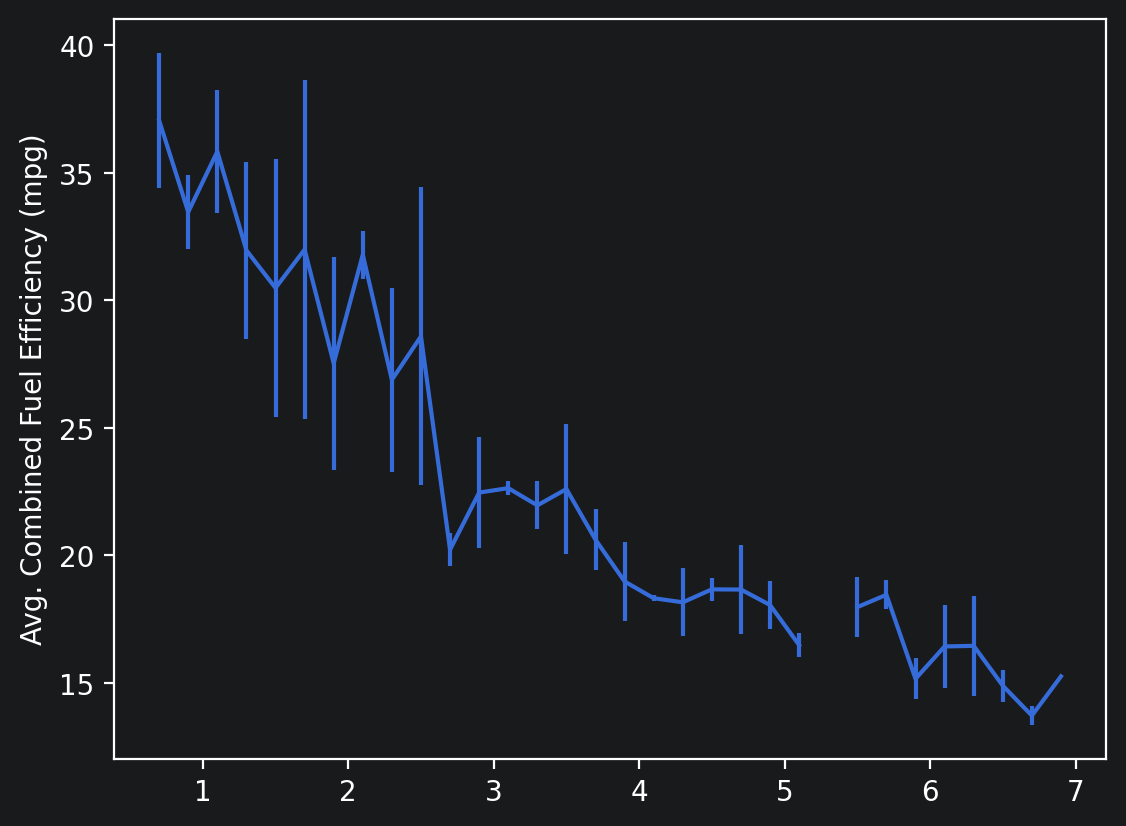

In [43]:
comb_mean = fuel_econ['comb'].groupby(displ_binned, observed=False).mean()
comb_std = fuel_econ['comb'].groupby(displ_binned, observed=False).std()

plt.errorbar(x=bin_centers, y=comb_mean, yerr=comb_std)
plt.ylabel('Avg. Combined Fuel Efficiency (mpg)');

In [44]:
## compute statistics in a rolling window
# df_window = df.sort_values('num_var1').rolling(15)
# x_winmean = df_window.mean()['num_var1']
# y_median = df_window.median()['num_var2']
# y_q1 = df_window.quantile(.25)['num_var2']
# y_q3 = df_window.quantile(.75)['num_var2']
#
# ## plot the summarized data
# base_color = sns.color_palette()[0]
# line_color = sns.color_palette('dark')[0]
# plt.scatter(data = df, x = 'num_var1', y = 'num_var2')
# plt.errorbar(x = x_winmean, y = y_median, c = line_color)
# plt.errorbar(x = x_winmean, y = y_q1, c = line_color, linestyle = '--')
# plt.errorbar(x = x_winmean, y = y_q3, c = line_color, linestyle = '--')
#
# plt.xlabel('num_var1')
# plt.ylabel('num_var2')

In [45]:
# bin_edges = np.arange(-3, df['num_var'].max()+1/3, 1/3)
# g = sb.FacetGrid(data = df, hue = 'cat_var', size = 5)
# g.map(plt.hist, "num_var", bins = bin_edges, histtype = 'step')
# g.add_legend()

In [46]:
# def freq_poly(x, bins = 10, **kwargs):
#     """ Custom frequency polygon / line plot code. """
#     # set bin edges if none or int specified
#     if type(bins) == int:
#         bins = np.linspace(x.min(), x.max(), bins+1)
#     bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
#
#     # compute counts
#     data_bins = pd.cut(x, bins, right = False,
#                        include_lowest = True)
#     counts = x.groupby(data_bins).count()
#
#     # create plot
#     plt.errorbar(x = bin_centers, y = counts, **kwargs)
#
# bin_edges = np.arange(-3, df['num_var'].max()+1/3, 1/3)
# g = sb.FacetGrid(data = df, hue = 'cat_var', size = 5)
# g.map(freq_poly, "num_var", bins = bin_edges)
# g.add_legend()

### Summary


In [47]:
# Scatter plots = 2 quantitative vars
# Clustered Bar Charts = 2 qualitative vars
# Heatmaps = 2D histogram
# Violin Plots & Box Plots = 1 quantitative var & 1 qualitative var

/tmp/ipykernel_35924/1702511566.py:4: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(0,0.5,s = 1e4, c = sns.color_palette()[0], alpha = 0.5)
/tmp/ipykernel_35924/1702511566.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(0,-0.5,s = 1e4, c = sns.color_palette()[1], alpha = 0.5)
/tmp/ipykernel_35924/1702511566.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which sho

([], [])

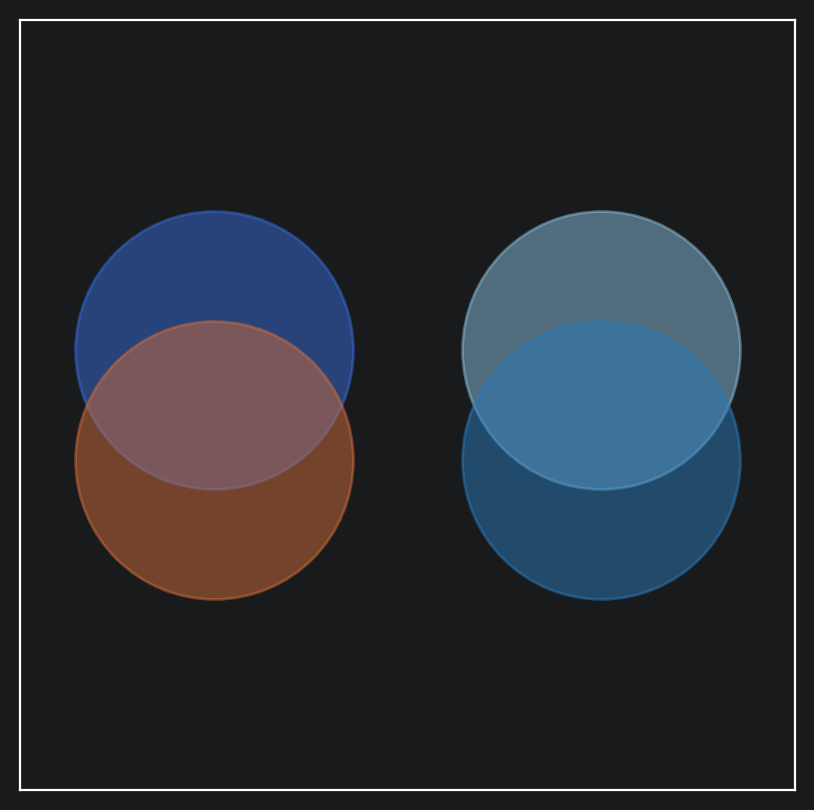

In [48]:
plt.figure(figsize = [5,5])

# left: qualitative points
plt.scatter(0,0.5,s = 1e4, c = sns.color_palette()[0], alpha = 0.5)
plt.scatter(0,-0.5,s = 1e4, c = sns.color_palette()[1], alpha = 0.5)

# right: quantitative points
plt.scatter(1,0.5,s = 1e4, c = sns.color_palette('Blues')[2], alpha = 0.5)
plt.scatter(1,-0.5,s = 1e4, c = sns.color_palette('Blues')[4], alpha = 0.5)

# set axes for point overlap
plt.xlim(-0.5,1.5)
plt.ylim(-3.5,3.5)
plt.xticks([])
plt.yticks([])

In [49]:
# g = sb.FacetGrid(data = df, col = 'cat_var2', row = 'cat_var1', size = 2.5,margin_titles = True)
# g.map(plt.scatter, 'num_var1', 'num_var2')

### Swarm Plots

/home/oleg/Developer/GitHub/AiNotebooks/ai-notebooks/ai_notebooks/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 63.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/oleg/Developer/GitHub/AiNotebooks/ai-notebooks/ai_notebooks/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 75.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/oleg/Developer/GitHub/AiNotebooks/ai-notebooks/ai_notebooks/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 81.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/oleg/Developer/GitHub/AiNotebooks/ai-notebooks/ai_notebooks/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 80.7% of th

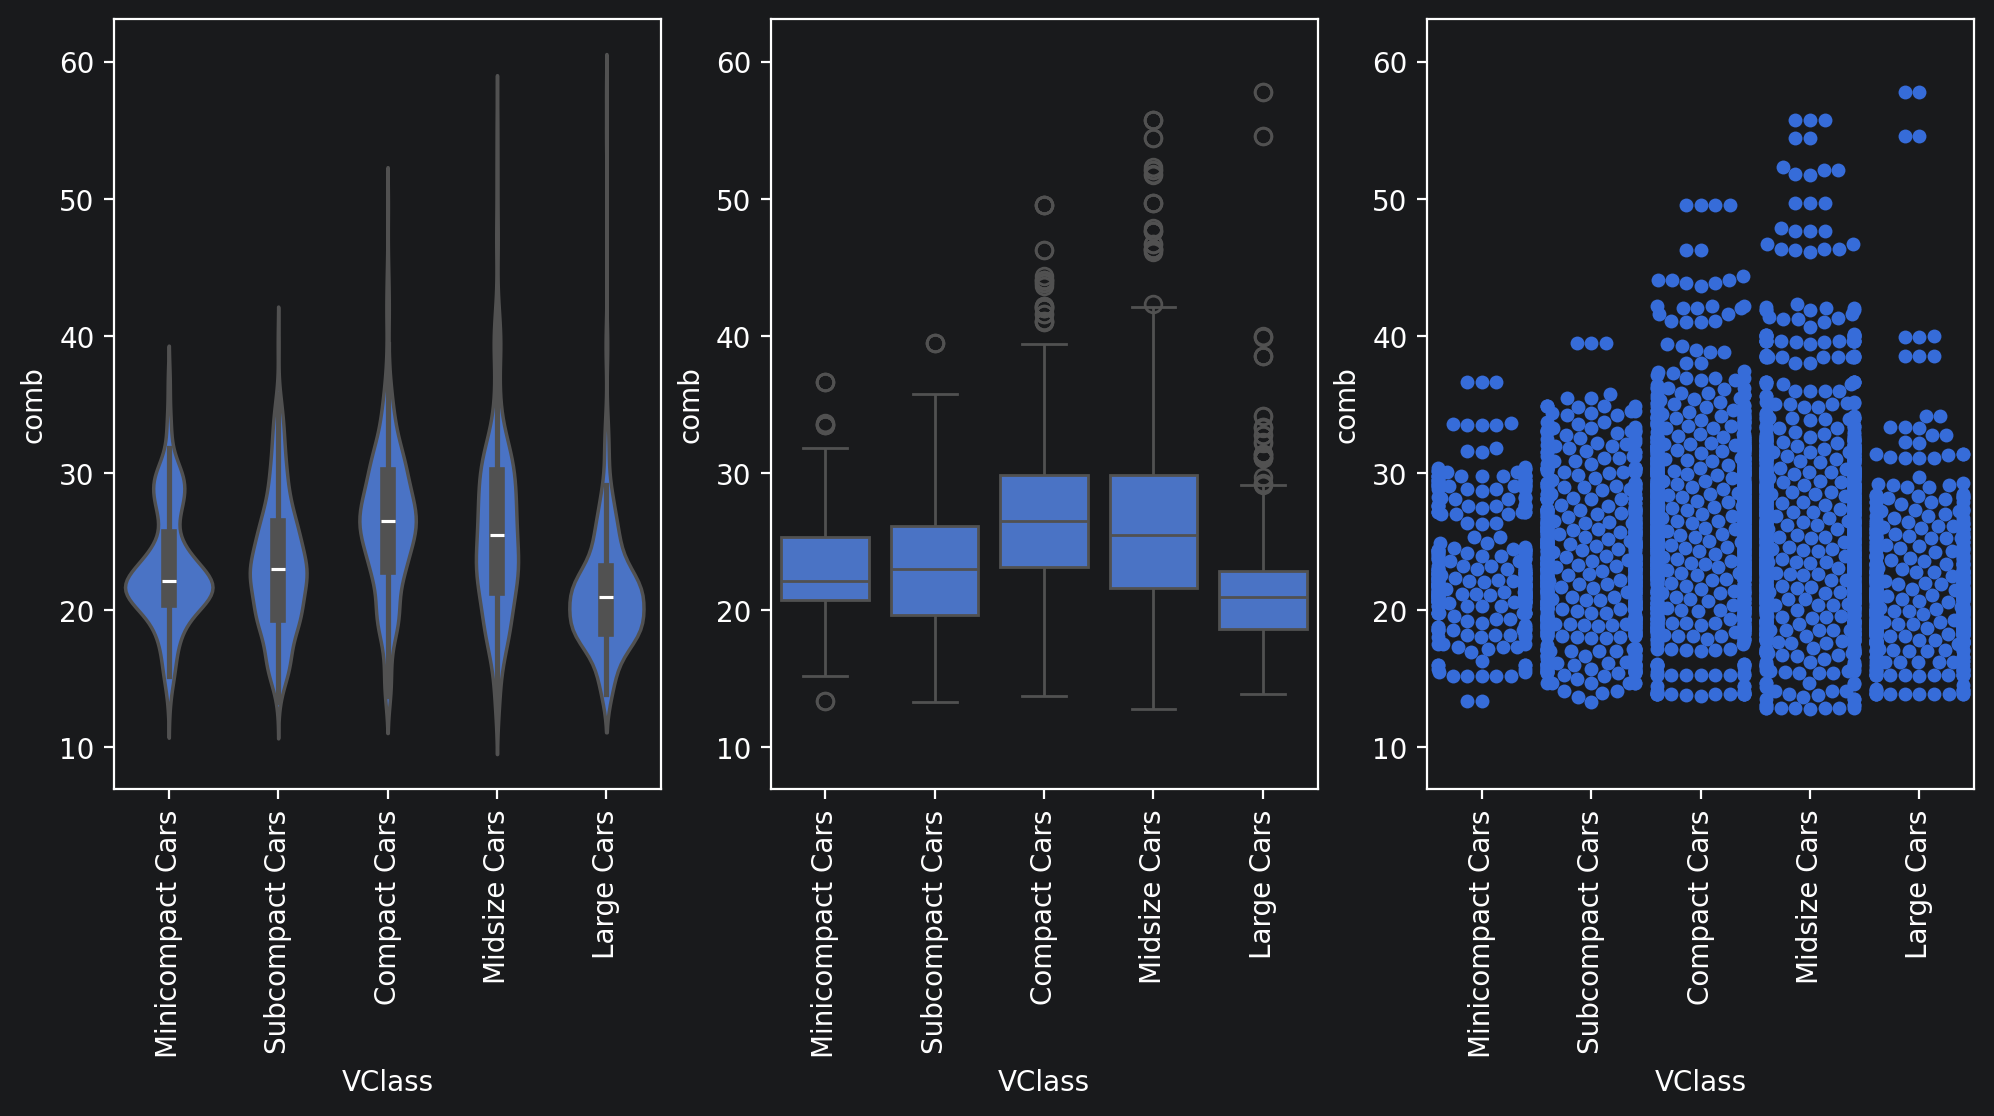

In [50]:

plt.figure(figsize = [12, 5])
base_color = sns.color_palette()[0]

# left plot: violin plot
plt.subplot(1, 3, 1)
ax1 = sns.violinplot(data = fuel_econ, x = 'VClass', y = 'comb', color = base_color)
plt.xticks(rotation=90);

# center plot: box plot
plt.subplot(1, 3, 2)
sns.boxplot(data = fuel_econ, x = 'VClass', y = 'comb', color = base_color)
plt.ylim(ax1.get_ylim()) # set y-axis limits to be same as left plot
plt.xticks(rotation=90);

# right plot: swarm plot
plt.subplot(1, 3, 3)
sns.swarmplot(data = fuel_econ,x = 'VClass', y = 'comb', color = base_color)
plt.ylim(ax1.get_ylim()) # set y-axis limits to be same as left plot
plt.xticks(rotation=90);


### Rug and Strip Plots

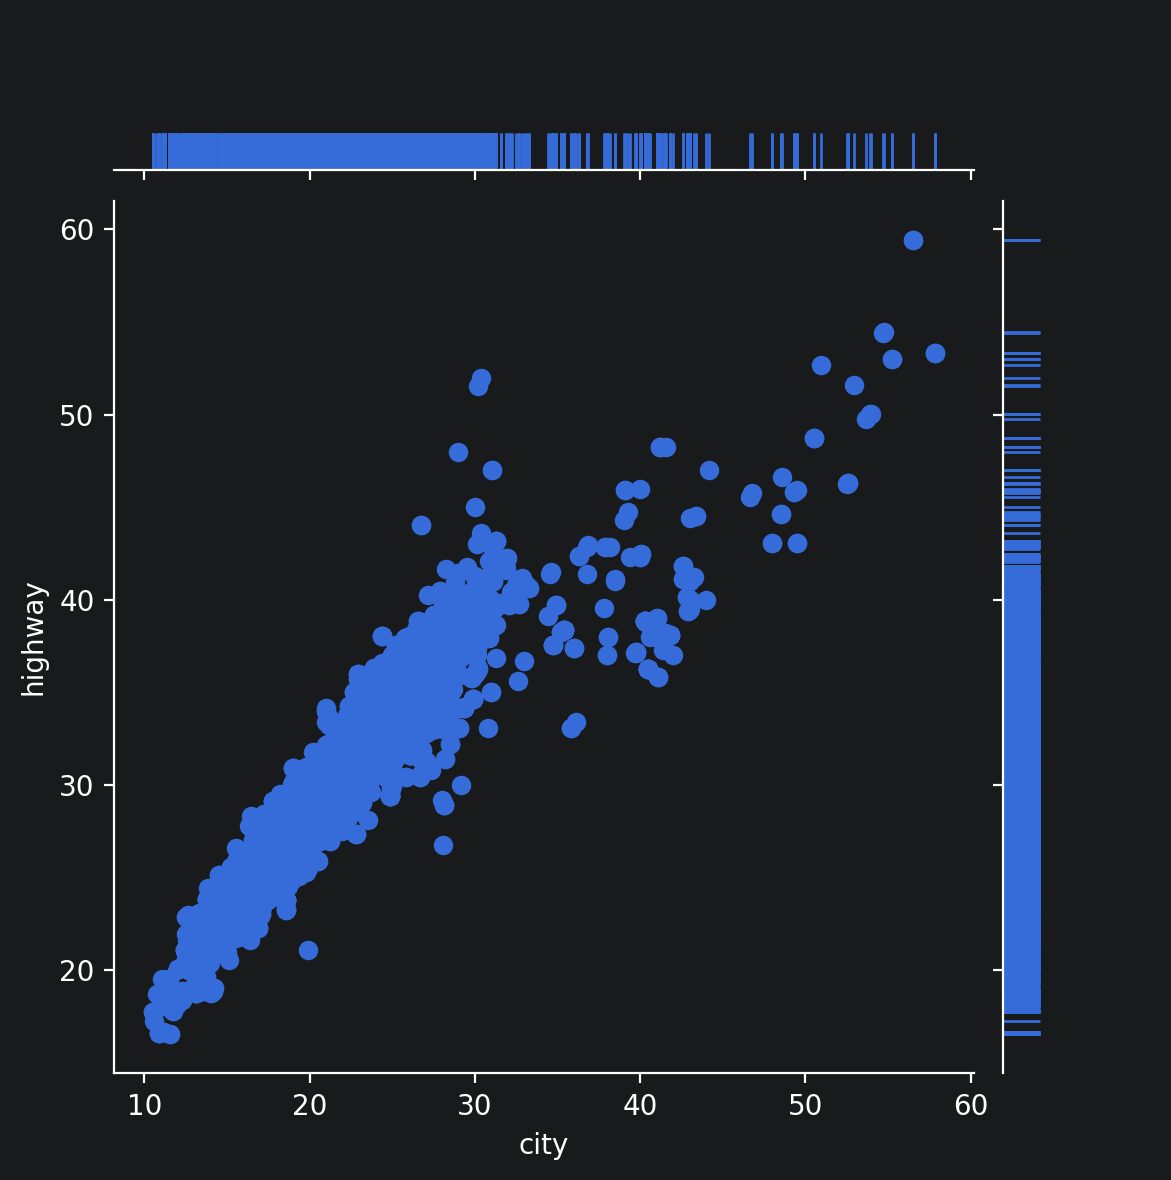

In [51]:
g = sns.JointGrid(data = fuel_econ, x = 'city', y = 'highway')
g.plot_joint(plt.scatter)
g.plot_marginals(sns.rugplot, height = 0.25)

<Axes: xlabel='comb', ylabel='VClass'>

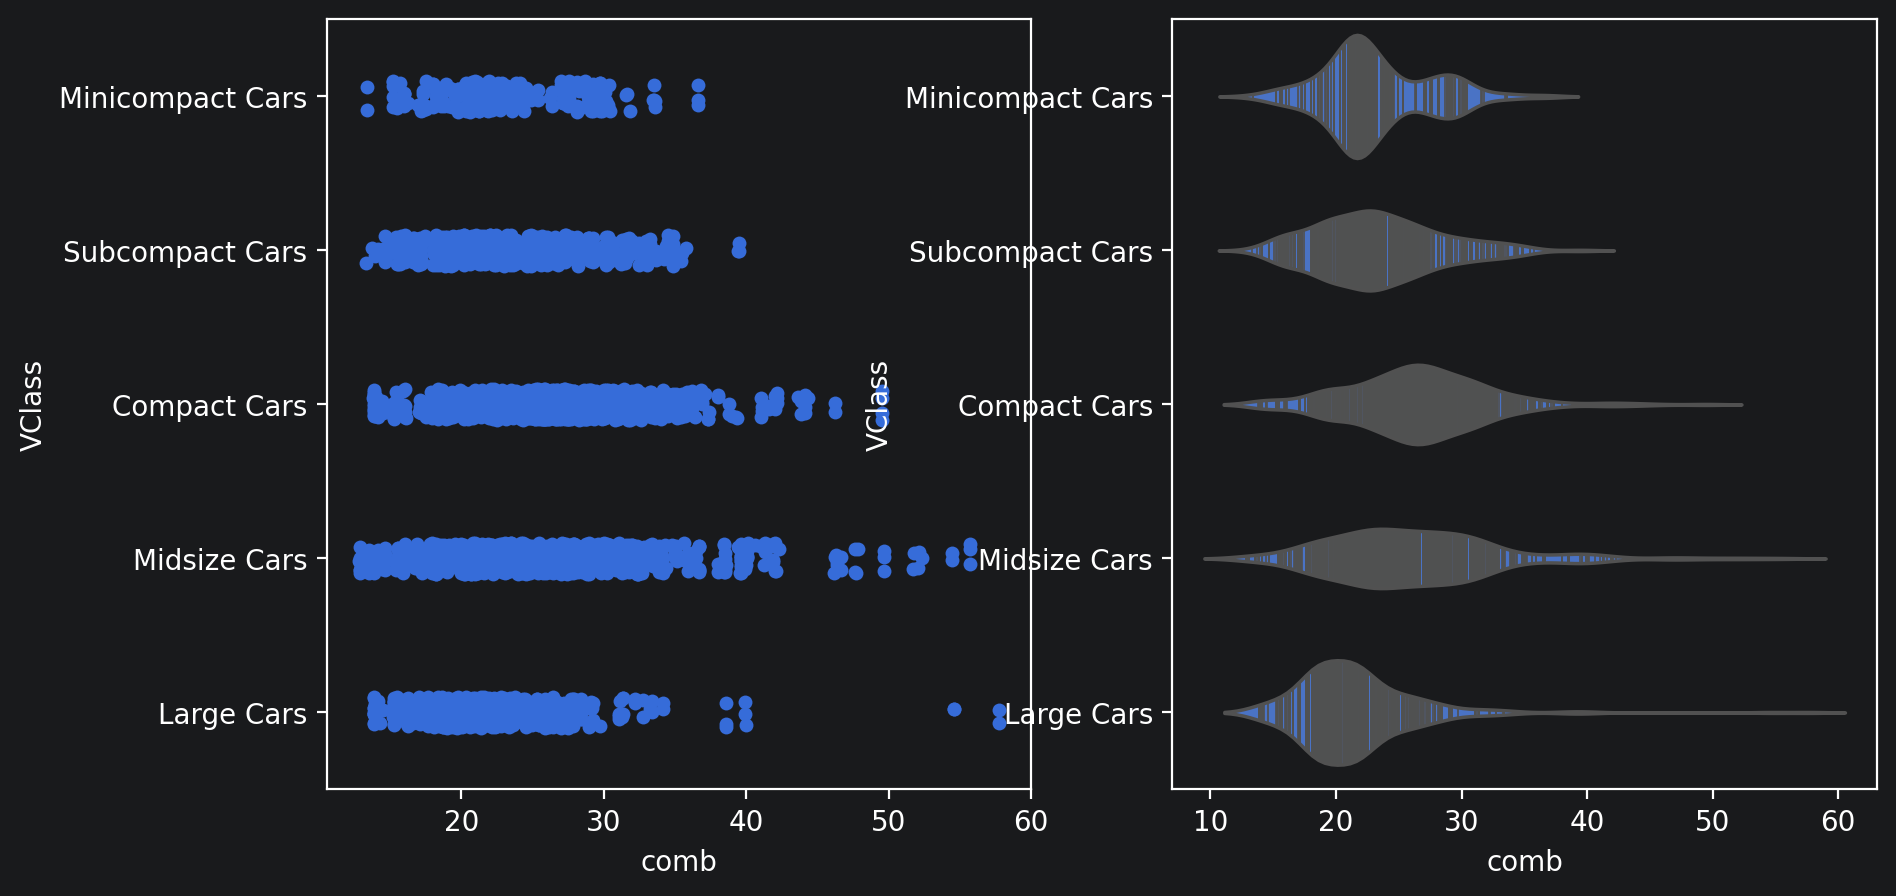

In [52]:
# Swarm plot

plt.figure(figsize = [10, 5])
base_color = sns.color_palette()[0]

# left plot: strip plot
plt.subplot(1, 2, 1)
ax1 = sns.stripplot(data = fuel_econ, x = 'comb', y = 'VClass', color = base_color)

# right plot: violin plot with inner strip plot as lines
plt.subplot(1, 2, 2)
sns.violinplot(data = fuel_econ, x = 'comb', y = 'VClass', color = base_color, inner = 'stick')

### Stacked Plots

(0.0, 2.0)

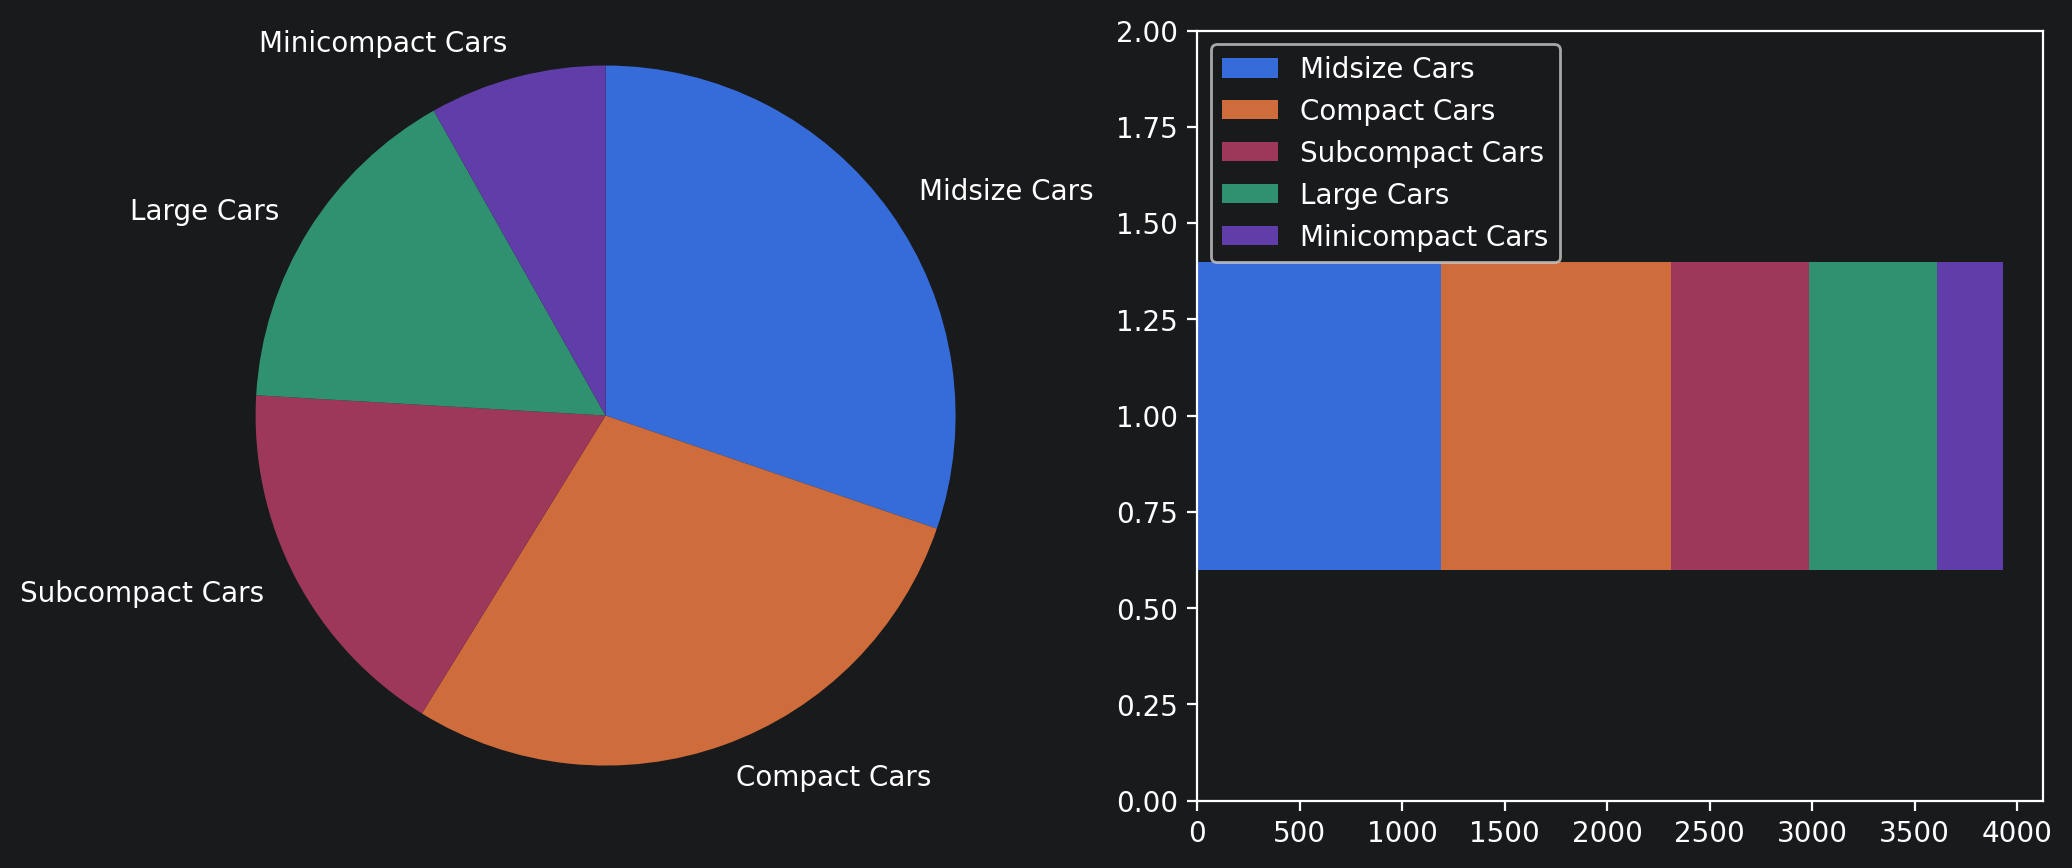

In [53]:
# pre-processing: count and sort by the number of instances of each category
sorted_counts = fuel_econ['VClass'].value_counts()

# establish the Figure
plt.figure(figsize = [12, 5])

# left plot: pie chart
plt.subplot(1, 2, 1)
plt.pie(sorted_counts, labels = sorted_counts.index, startangle = 90, counterclock = False);
plt.axis('square');

# right plot: horizontally stacked bar
plt.subplot(1, 2, 2)
baseline = 0
for i in range(sorted_counts.shape[0]):
    plt.barh(y = 1, width = sorted_counts.iloc[i], left = baseline)
    baseline += sorted_counts.iloc[i]

plt.legend(sorted_counts.index)  # add a legend for labeling
plt.ylim([0,2]) # give some vertical spacing around the bar

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Minicompact Cars'),
  Text(1, 0, 'Subcompact Cars'),
  Text(2, 0, 'Compact Cars'),
  Text(3, 0, 'Midsize Cars'),
  Text(4, 0, 'Large Cars')])

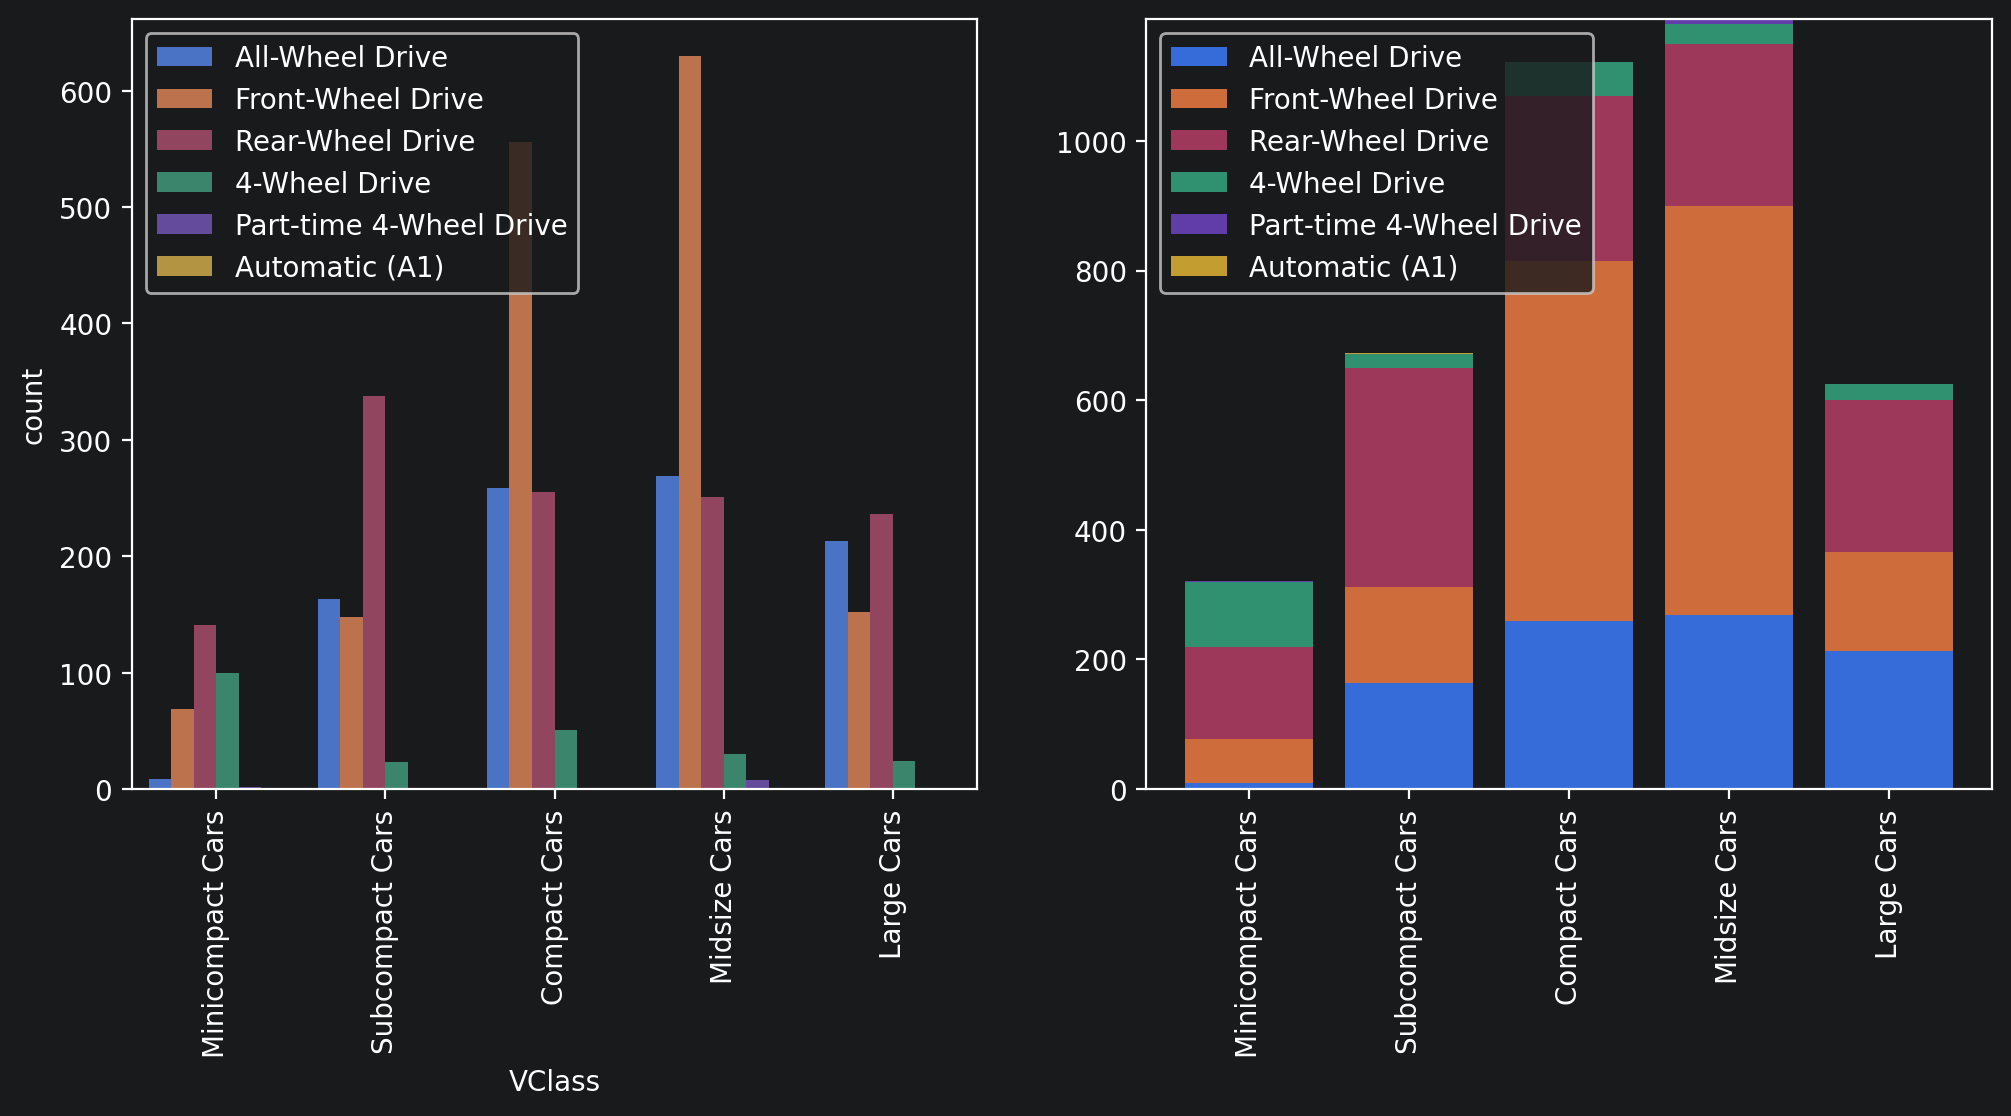

In [54]:

sedan_classes = ['Minicompact Cars', 'Subcompact Cars', 'Compact Cars', 'Midsize Cars', 'Large Cars']
drive_types = ['All-Wheel Drive', 'Front-Wheel Drive', 'Rear-Wheel Drive','4-Wheel Drive', 'Part-time 4-Wheel Drive', 'Automatic (A1)']

drives = pd.api.types.CategoricalDtype(ordered=True, categories=drive_types)

fuel_econ['drive'] = fuel_econ['drive'].astype(drives)


plt.figure(figsize = [12, 5])

# left plot: clustered bar chart, absolute counts
plt.subplot(1, 2, 1)
sns.countplot(data = fuel_econ, x = 'VClass', hue = 'drive', order = sedan_classes, hue_order = drive_types)
plt.legend()
plt.xticks(rotation=90)

# right plot: stacked bar chart, absolute counts
plt.subplot(1, 2, 2)

baselines = np.zeros(len(sedan_classes))
# for each second-variable category:
for i in range(len(drive_types)):
    # isolate the counts of the first category,
    cat2 = drive_types[i]
    inner_counts = fuel_econ[fuel_econ['drive'] == cat2]['VClass'].value_counts()
    # then plot those counts on top of the accumulated baseline
    plt.bar(x = np.arange(len(sedan_classes)), height = inner_counts[sedan_classes], bottom = baselines)
    baselines += inner_counts[sedan_classes]

plt.xticks(np.arange(len(sedan_classes)), sedan_classes)
plt.legend(drive_types)
plt.xticks(rotation=90)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Minicompact Cars'),
  Text(1, 0, 'Subcompact Cars'),
  Text(2, 0, 'Compact Cars'),
  Text(3, 0, 'Midsize Cars'),
  Text(4, 0, 'Large Cars')])

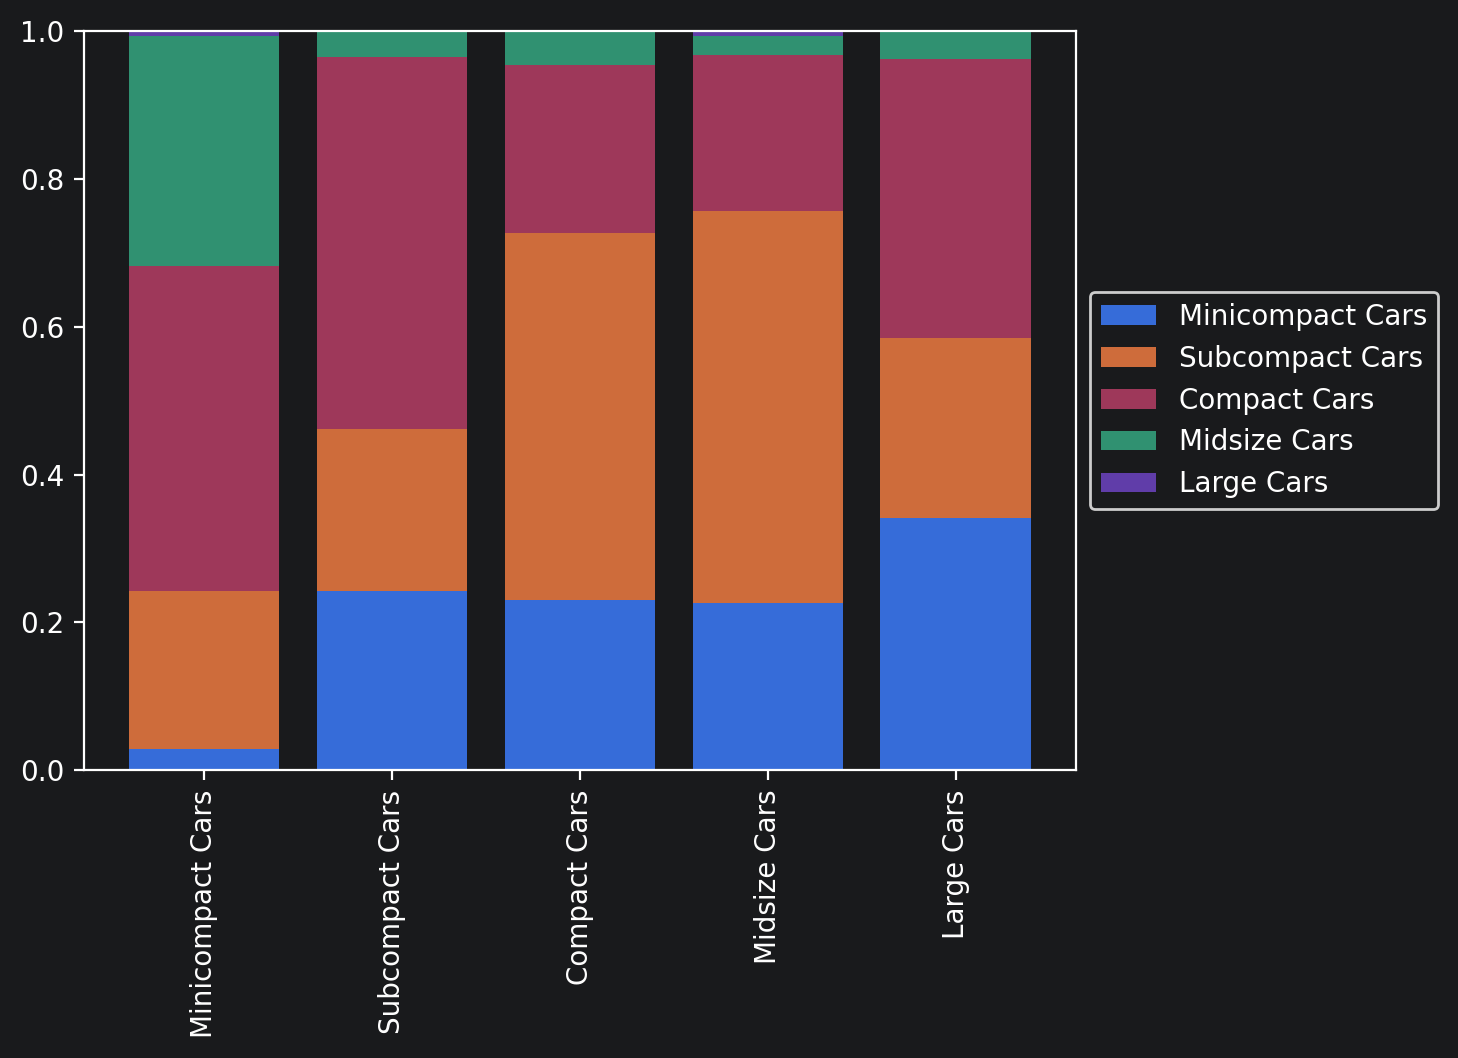

In [55]:
artists = [] # for storing references to plot elements
baselines = np.zeros(len(sedan_classes))
cat1_counts = fuel_econ['VClass'].value_counts()

# for each second-variable category:
for i in range(len(drive_types)):
    # isolate the counts of the first category,
    cat2 = drive_types[i]
    inner_counts = fuel_econ[fuel_econ['drive'] == cat2]['VClass'].value_counts()
    inner_props = inner_counts / cat1_counts
    # then plot those counts on top of the accumulated baseline
    bars = plt.bar(x = np.arange(len(sedan_classes)),
                   height = inner_props[sedan_classes],
                   bottom = baselines)
    artists.append(bars)
    baselines += inner_props[sedan_classes]

plt.xticks(np.arange(len(sedan_classes)), sedan_classes)
plt.legend(artists, sedan_classes, framealpha = 1, bbox_to_anchor = (1, 0.5), loc = 6);
plt.xticks(rotation=90)

### Q-Q Plots

In [56]:
# There might be cases where you are interested to see how closely your numeric data follows some hypothetical distribution. 
# This might be important for certain parametric statistical tests, like checking for assumptions of normality. 
# In cases like this, you can use a quantile-quantile plot, or Q-Q plot, to make a visual comparison between your data and your reference distribution

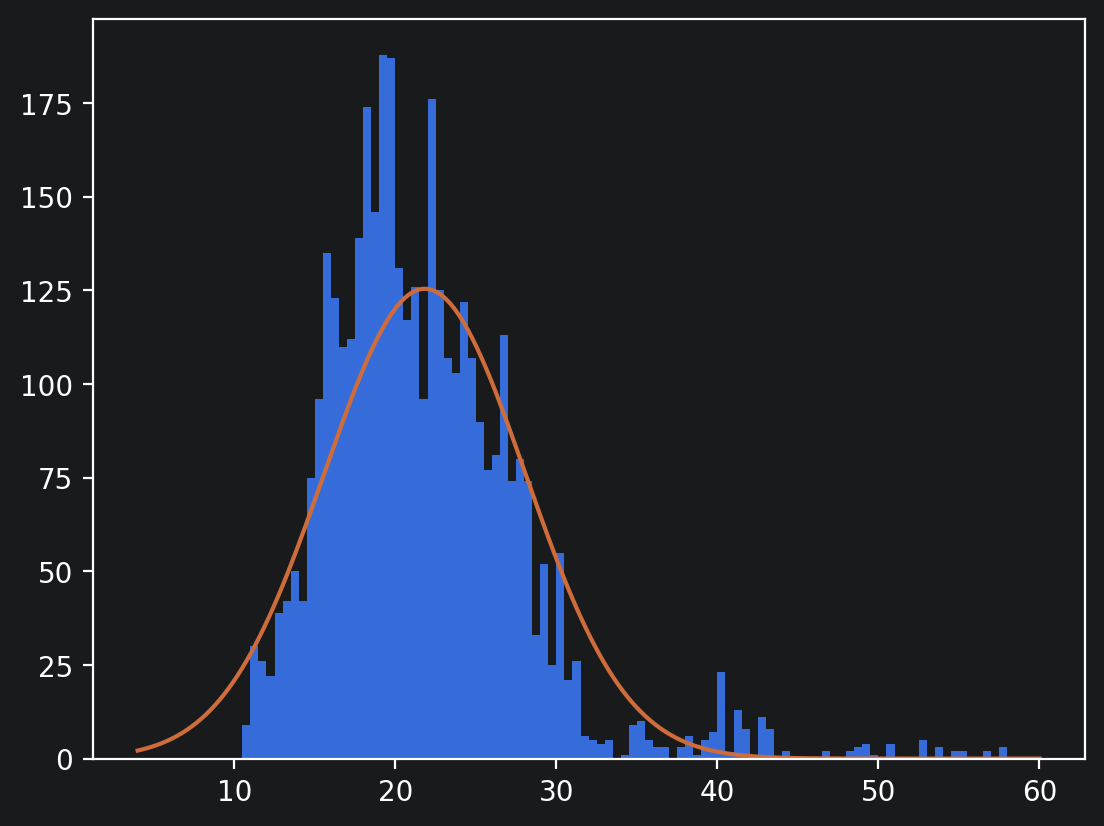

In [57]:
# create a histogram of the data
bin_size = 0.5
bin_edges = np.arange(4, 60 + bin_size, bin_size)
plt.hist(data = fuel_econ, x = 'city', bins = bin_edges);

# overlay a theoretical normal distribution on top
samp_mean = fuel_econ['city'].mean()
samp_sd = fuel_econ['city'].std()

from scipy.stats import norm
x = np.linspace(4, 60, 200)
y = norm.pdf(x, samp_mean, samp_sd) # normal distribution heights
y *= fuel_econ.shape[0]*  bin_size # scale the distribution height

plt.plot(x, y)

Text(0, 0.5, 'Observed Standard Scores')

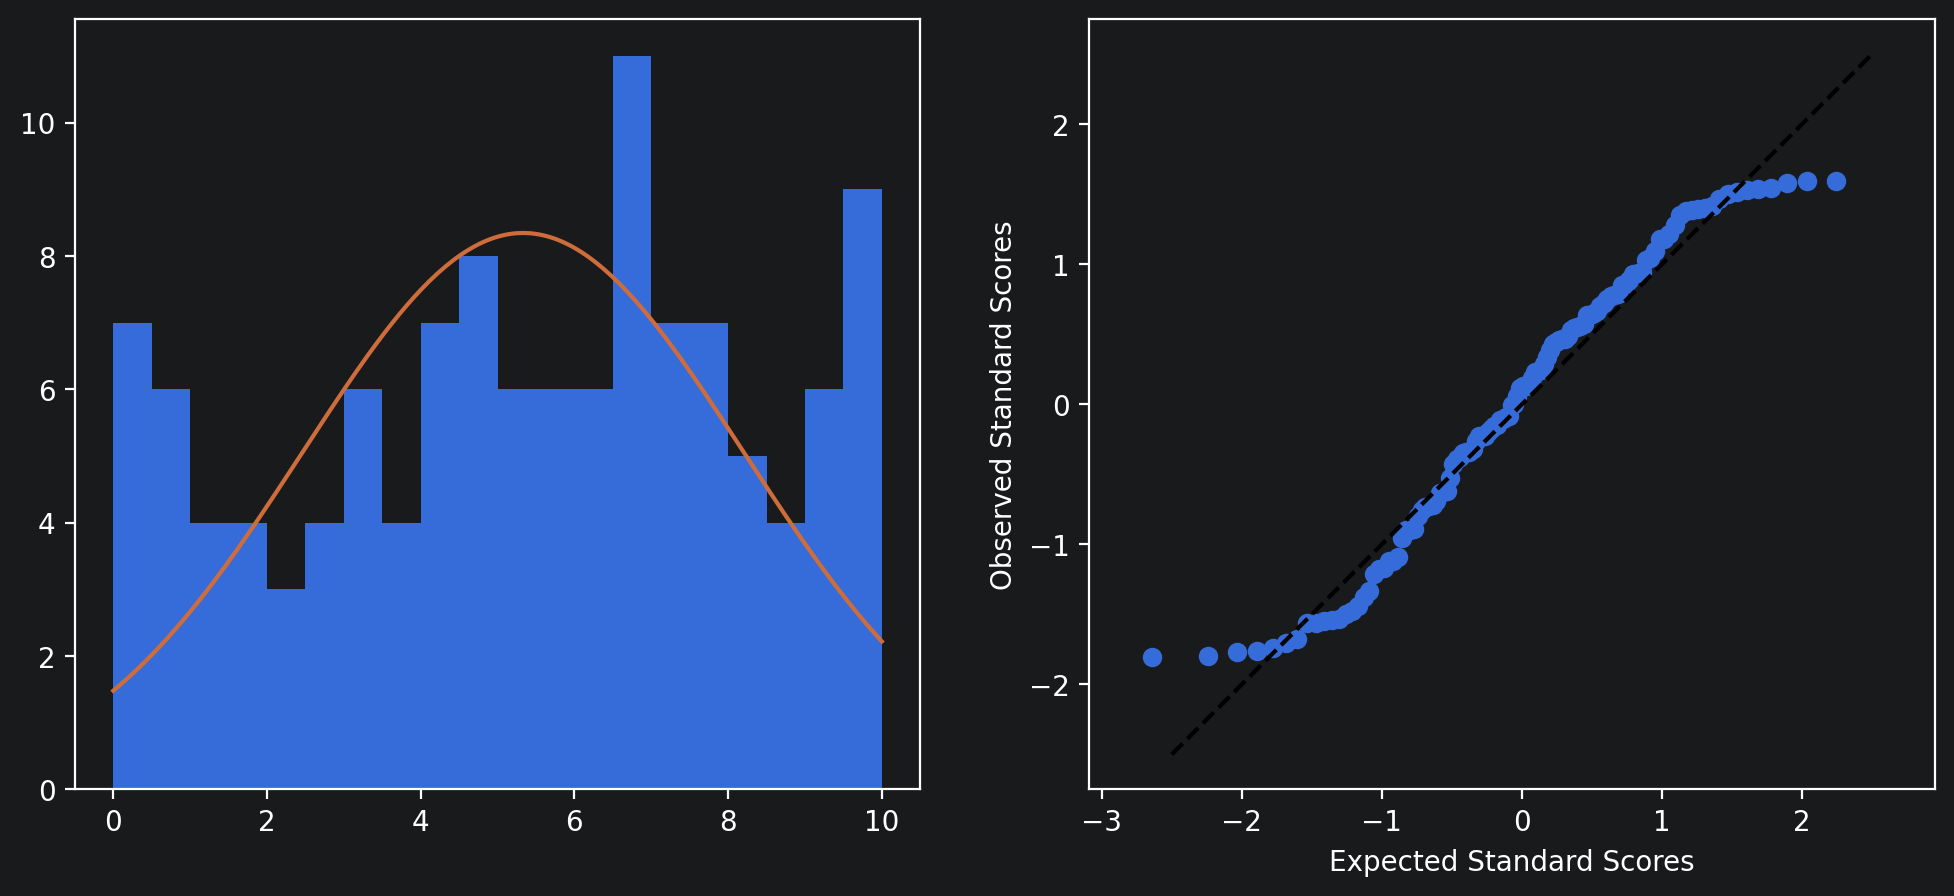

In [58]:
# generate the data
np.random.seed(8322489)

n_points = 120
unif_data = np.random.uniform(0, 10, n_points)

# set up the figure
plt.figure(figsize = [12, 5])

# left subplot: plot the data
plt.subplot(1, 2, 1)
bin_size = 0.5
bin_edges = np.arange(0, 10 + bin_size, bin_size)
plt.hist(x = unif_data, bins = bin_edges);

# overlay a theoretical normal distribution on top
samp_mean = unif_data.mean()
samp_sd = unif_data.std()

from scipy.stats import norm
x = np.linspace(0, 10, 200)
y = norm.pdf(x, samp_mean, samp_sd) # normal distribution heights
y *= n_points*  bin_size # scale the distribution height
plt.plot(x, y)

# right subplot: create a Q-Q plot
plt.subplot(1, 2, 2)

qs = (np.arange(n_points) - .5) / n_points
expected_scores = norm.ppf(qs)
data_scores = (np.sort(unif_data) - samp_mean) / samp_sd

plt.scatter(expected_scores, data_scores)
plt.plot([-2.5,2.5],[-2.5,2.5],'--', color = 'black')
plt.axis('equal')
plt.xlabel('Expected Standard Scores')
plt.ylabel('Observed Standard Scores')

### Ridgeline Plots

In [59]:
# One of the hot new visualization types from recent years is the ridgeline plot. 
# In a nutshell, the ridgeline plot is a series of vertically faceted line plots or density curves, but with somewhat overlapping y-axes.

In [60]:
# https://seaborn.pydata.org/examples/kde_ridgeplot.html